# Deep05. Attention 기반 Seq2seq 한영 번역기

`korean-english-park` 병렬 말뭉치로 **Bahdanau Attention 기반 Seq2seq 번역기**를 만든다.

## 루브릭

| 학습목표 | 평가기준 |
|---|---|
| 1. 번역기 모델 학습에 필요한 텍스트 데이터 전처리가 한국어 포함하여 잘 이루어졌다. | 구두점, 대소문자, 띄어쓰기, 한글 형태소분석 등 번역기 모델에 요구되는 전처리가 정상적으로 진행되었다. |
| 2. Attentional Seq2seq 모델이 정상적으로 구동된다. | seq2seq 모델 훈련 과정에서 training loss가 안정적으로 떨어지면서 학습이 진행됨이 확인되었다. |
| 3. 테스트 결과 의미가 통하는 수준의 번역문이 생성되었다. | 테스트용 디코더 모델이 정상적으로 만들어져서, 정답과 어느 정도 유사한 영어 번역이 진행됨을 확인하였다. |


## 진행 순서

```
 1. 환경 · 라이브러리 · 한글 폰트 · Mecab 준비
 2. 데이터 로드 & EDA
 3. 데이터 정제 (1) — 중복 제거 → cleaned_corpus
 4. 데이터 정제 (2) — 노이즈 패턴 제거 · 언어별 정규식 전처리
 5. 토큰화 & 길이 필터 → kor_corpus / eng_corpus
 6. 텐서 변환 & DataLoader (배치별 동적 패딩)
 7. 모델 설계 — Encoder / BahdanauAttention(패딩 마스킹) / Decoder(input feeding)
 8. 훈련 준비 — Optimizer & Loss & train_step
 9. 훈련 실행 + 매 epoch 예문 번역 + Attention Map
10. 실험 — 구성별 비교
11. 최종 결과
12. 회고
```

## 실행 플로우

```
[ 원본 ]  korean-english-park.train.ko / .en   (94,123 쌍)
                          |
                          v
[ 3 ]  set 기반 중복 제거 (zip 순회, 한국어 기준 첫 쌍만 유지)  ->  cleaned_corpus  (77,591 쌍)
                          |
                          v
[ 4 ]  노이즈 패턴 제거  보일러플레이트 / 제목줄 / 어휘풀이 / 한글0자 / 소스=타깃
                          |
          +---------------+-----------------+
          v (한국어)                          v (영어)
        라틴문자 소문자화                     소문자화
        곡선 따옴표 -> ASCII                  곡선 따옴표 -> ASCII
        숫자 내부 . , 보호                    숫자 내부 . , 보호
        구두점 분리  ? . ! ,                  구두점 분리  ? . ! ,
        [^가-힣a-z0-9?.!,'] -> 공백           contractions 정규화
        다중 공백 축소                        [^a-z0-9?.!,'] -> 공백 / 공백 축소
          |                                   |
          +---------------+-------------------+
                          v
              빈 문장 제거 -> 정제 후 (한국어, 영어) 중복 재제거   (76,809 쌍)
                          |
                          v
[ 5 ]  Mecab.morphs() -> 공백 결합 (한국어만)
                          |
                          v
              SentencePiece 학습  vocab 16,000 · pad0 bos1 eos2 unk3 · coverage 1.0
                          |
                          v
              encode -> id       영어만 [bos] ... [eos] 부착
                          |
                          v
              양쪽 모두 길이 <= 40 인 쌍만 선별  ->  kor_corpus / eng_corpus
                          |
                          v
[ 6 ]  post-padding -> src / trg_input / trg_label   (N, 40) LongTensor
              TensorDataset -> DataLoader (batch 64, collate_trim 으로 배치별 길이 절단)
                          |
                          v
[ 7 ]  Encoder(GRU)  pack_padded_sequence 로 <pad> 를 건너뛴 final hidden
                     -> encoder_outputs
                     -> BahdanauAttention(mask)  <pad> 위치를 -inf 로 마스킹 -> context
                     -> Decoder(GRU)  입력 = [embedded ; context]  (input feeding)
                     -> prediction, hidden, attention
                          |
                          v
[ 8~9 ] AdamW(lr 1e-3, weight_decay 0 == Adam) + CrossEntropyLoss(ignore_index=0)
         + clip_grad_norm(1.0)
         train_step() 만 사용 (eval_step 없음) — 훈련/검증을 나누지 않는 것이 프로젝트 조건
         run_experiment() : 실행마다 시드 리셋 · 구성별 체크포인트 · history json 저장
         매 epoch 예문 4개 번역 · train loss 가 갱신된 epoch 의 best.pt 만 유지
                          |
                          v
[10~11] 구성 비교 (A / B / A+dropout)  ->  4문장 정성 평가로 epoch 선택
         ->  최종 번역 + Attention Map
```


---
# 1. 환경 · 라이브러리 · 한글 폰트 · Mecab 준비

### 1-1. 라이브러리

In [1]:
import os
import re
import time
import json
import glob
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import sentencepiece as spm
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

# ---- 경로 ----
BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, 'data')
KOR_PATH = os.path.join(DATA_DIR, 'korean-english-park.train.ko')
ENG_PATH = os.path.join(DATA_DIR, 'korean-english-park.train.en')

# ---- 시드 ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('[ 환경 ]')
print(f'torch       : {torch.__version__}')
print(f'device      : {device}')
print(f'데이터 경로  : {DATA_DIR}')

[ 환경 ]
torch       : 2.11.0+cu128
device      : cuda
데이터 경로  : C:\Aiffel\AIFFEL_quest_rs\GoingDeeper\Deep05\data


### 1-2. matplotlib 한글 폰트

In [2]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Windows 기본 한글 폰트(맑은 고딕). 없으면 설치된 한글 폰트를 자동으로 찾아 사용한다.
installed = {f.name for f in fm.fontManager.ttflist}
for candidate in ["Malgun Gothic", "NanumBarunGothic", "NanumGothic", "AppleGothic"]:
    if candidate in installed:
        font_name = candidate
        break
else:
    font_name = plt.rcParams["font.family"][0]
    print("한글 폰트를 찾지 못했습니다. Attention Map의 한글이 깨질 수 있습니다.")

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {font_name}")

설정된 폰트: Malgun Gothic


### 1-3. 한국어 형태소 분석기

아래 셀을 실행하여 Windows용 휠(`mecab_ko-1.0.2-cp312-cp312-win_amd64`)을 설치한다.
설치 후에는 커널을 재시작해야 한다.

In [3]:
# !pip install mecab-ko mecab-ko-dic

In [4]:
def get_ko_tokenizer():
    """한국어 형태소 분석기를 확보하고 (morphs 함수, 이름) 을 돌려준다.

    Windows 에서는 MeCab 바이너리를 찾지 못해 실패하는 경우가 많다. 
    아래 순서로 시도하고, 성공한 경로를 이름과 함께 반환한다.

        1) konlpy.tag.Mecab   : 명세가 요구하는 1순위
        2) mecab_ko           : 같은 MeCab-ko 엔진. konlpy 래퍼만 우회한다
        3) kiwipiepy.Kiwi     : 이미 설치되어 있는 최후 보루
    """
    # ---- 1) KoNLPy Mecab ----
    try:
        from konlpy.tag import Mecab
        tagger = Mecab()
        tagger.morphs('테스트')
        return tagger.morphs, 'konlpy.tag.Mecab'
    except Exception as e:
        print(f'[1] konlpy.tag.Mecab  사용 불가 -> {type(e).__name__}: {e}')

    # ---- 2) mecab-ko 패키지 직접 사용 ----
    try:
        import mecab_ko
        try:
            tagger = mecab_ko.MeCab()
            tagger.morphs('테스트')
            return tagger.morphs, 'mecab_ko.MeCab'
        except AttributeError:
            pass

        try:
            tagger = mecab_ko.Tagger()
        except Exception:
            import mecab_ko_dic
            tagger = mecab_ko.Tagger(mecab_ko_dic.MECAB_ARGS)

        def morphs(text):
            # parse() 는 "표층형\t품사정보" 줄들을 내놓고 마지막에 EOS 가 붙는다.
            return [line.split('\t')[0] for line in tagger.parse(text).splitlines()
                    if line and line != 'EOS']

        morphs('테스트')
        return morphs, 'mecab_ko.Tagger'
    except Exception as e:
        print(f'[2] mecab_ko          사용 불가 -> {type(e).__name__}: {e}')

    # ---- 3) Kiwi ----
    try:
        from kiwipiepy import Kiwi
        kiwi = Kiwi()

        def morphs(text):
            return [t.form for t in kiwi.tokenize(text)]

        morphs('테스트')
        return morphs, 'kiwipiepy.Kiwi'
    except Exception as e:
        print(f'[3] kiwipiepy.Kiwi    사용 불가 -> {type(e).__name__}: {e}')

    raise RuntimeError('사용 가능한 형태소 분석기가 없습니다. pip install mecab-ko mecab-ko-dic')


ko_morphs, KO_TOKENIZER_NAME = get_ko_tokenizer()

print(f'\n>> 사용 분석기 : {KO_TOKENIZER_NAME}')
for s in ['오바마는 대통령이다.', '일곱 명의 사망자가 발생했다.']:
    print(f'   {s}  ->  {ko_morphs(s)}')

[1] konlpy.tag.Mecab  사용 불가 -> Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/

>> 사용 분석기 : mecab_ko.Tagger
   오바마는 대통령이다.  ->  ['오바마', '는', '대통령', '이', '다', '.']
   일곱 명의 사망자가 발생했다.  ->  ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']


---
# 2. 데이터 로드 & EDA

### 2-1. 데이터 로드 · len · 샘플 확인

In [5]:
with open(KOR_PATH, encoding='utf-8') as f:
    kor_lines = f.read().splitlines()
with open(ENG_PATH, encoding='utf-8') as f:
    eng_lines = f.read().splitlines()

print(f'한국어 개수 : {len(kor_lines):,}')
print(f'영어   개수 : {len(eng_lines):,}')
assert len(kor_lines) == len(eng_lines), '줄 수가 달라 병렬 쌍이 성립하지 않는다'

print('\n[ 샘플 5쌍 ]')
for i in range(5):
    print(f'  [{i}] KO : {kor_lines[i]}')
    print(f'      EN : {eng_lines[i]}')

한국어 개수 : 94,123
영어   개수 : 94,123

[ 샘플 5쌍 ]
  [0] KO : 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
      EN : Much of personal computing is about "can you top this?"
  [1] KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
      EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  [2] KO : 그러나 이것은 또한 책상도 필요로 하지 않는다.
      EN : Like all optical mice, But it also doesn't need a desk.
  [3] KO : 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
      EN : uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
  [4] KO : 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.
      EN : Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world'

### 2-2. 중복

In [6]:
n_pair = len(kor_lines)
u_ko   = len(set(kor_lines))
u_en   = len(set(eng_lines))
u_both = len(set(zip(kor_lines, eng_lines)))

print(f'원본 쌍             : {n_pair:,}')
print(f'한국어 unique       : {u_ko:,}  ({u_ko / n_pair:.1%})')
print(f'영어   unique       : {u_en:,}  ({u_en / n_pair:.1%})')
print(f'(한국어, 영어) unique : {u_both:,}')

# 두 종류의 '중복'은 성격이 전혀 다르다 -> 3절의 제거 기준이 여기서 결정된다.
print(f'\n같은 한국어에 다른 영어 : {u_both - u_ko:,}건  (모순된 지도신호 -> 제거)')
print(f'다른 한국어에 같은 영어 : {u_both - u_en:,}건  (정상적인 many-to-one -> 유지)')

원본 쌍             : 94,123
한국어 unique       : 77,591  (82.4%)
영어   unique       : 75,598  (80.3%)
(한국어, 영어) unique : 78,968

같은 한국어에 다른 영어 : 1,377건  (모순된 지도신호 -> 제거)
다른 한국어에 같은 영어 : 3,370건  (정상적인 many-to-one -> 유지)


### 2-3. 길이 분포

길이 컷을 정하기 위해 길이 분포를 확인한다. 여기서는 **표본 5,000건**으로 방향만 잡는다.
아래 수치는 한국어=형태소 수, 영어=공백 단어 수 + 2 로 잰 **참고용 근사**이고,
실제 필터가 쓰는 SentencePiece 조각 길이는 §5-2에서 전량으로 다시 측정한다.

In [7]:
ko_ws = np.array([len(s.split()) for s in kor_lines])   # 한국어 공백 토큰 수
en_ws = np.array([len(s.split()) for s in eng_lines])   # 영어 공백 토큰 수

# 형태소 길이는 표본으로 추정한다.
SAMPLE_N = 5000
sample_idx = random.sample(range(n_pair), SAMPLE_N)
ko_mp = np.array([len(ko_morphs(kor_lines[i])) for i in tqdm(sample_idx, desc='형태소 분석(표본)')])
en_ws_sample = en_ws[sample_idx]


def describe(name, arr):
    return {'구분': name,
            'mean': round(float(arr.mean()), 1),
            'median': int(np.median(arr)),
            'p75': int(np.percentile(arr, 75)),
            'p90': int(np.percentile(arr, 90)),
            'max': int(arr.max())}


df_len = pd.DataFrame([
    describe('한국어 (공백)', ko_ws),
    describe('영어   (공백)', en_ws),
    describe(f'한국어 (형태소, 표본 {SAMPLE_N:,})', ko_mp),
    describe(f'영어   (공백+특수토큰 2, 표본 {SAMPLE_N:,})', en_ws_sample + 2),
])
display(df_len)

형태소 분석(표본): 100%|██████████| 5000/5000 [00:00<00:00, 8480.32it/s] 


,구분,mean,median,p75,p90,max
0,한국어 (공백),14.0,14,18,23,82
1,영어 (공백),20.9,20,28,35,90
2,"한국어 (형태소, 표본 5,000)",29.1,28,38,48,93
3,"영어 (공백+특수토큰 2, 표본 5,000)",22.9,22,30,37,83


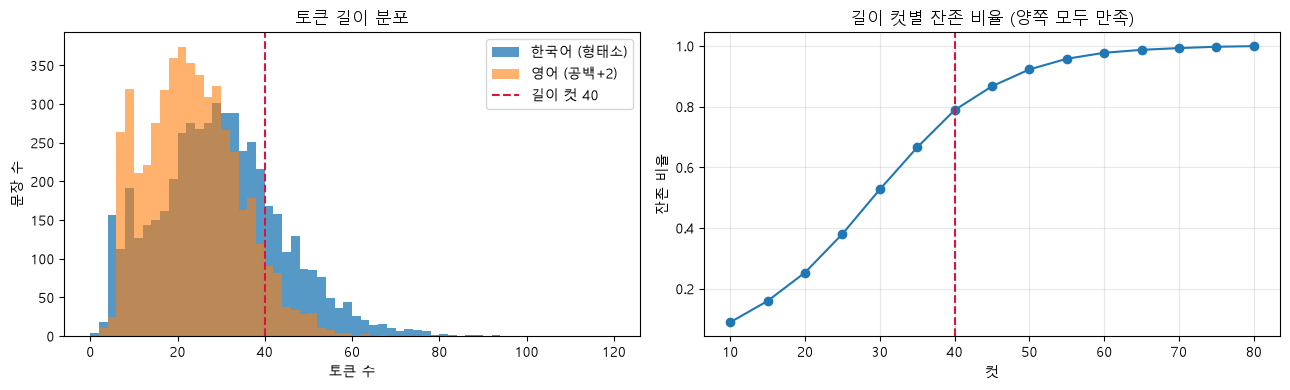

[ 길이 컷 후보 ]
   30 이하 -> 잔존  52.7%
   40 이하 -> 잔존  78.8%
   50 이하 -> 잔존  92.2%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ko_mp, bins=60, range=(0, 120), alpha=.75, label='한국어 (형태소)')
axes[0].hist(en_ws_sample + 2, bins=60, range=(0, 120), alpha=.6, label='영어 (공백+2)')
axes[0].axvline(40, color='crimson', ls='--', lw=1.5, label='길이 컷 40')
axes[0].set_title('토큰 길이 분포')
axes[0].set_xlabel('토큰 수'); axes[0].set_ylabel('문장 수'); axes[0].legend()

# 길이 컷 후보별 잔존율
cuts = list(range(10, 81, 5))
keep = [((ko_mp <= c) & (en_ws_sample + 2 <= c)).mean() for c in cuts]
axes[1].plot(cuts, keep, marker='o')
axes[1].axvline(40, color='crimson', ls='--', lw=1.5)
axes[1].set_title('길이 컷별 잔존 비율 (양쪽 모두 만족)')
axes[1].set_xlabel('컷'); axes[1].set_ylabel('잔존 비율'); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print('[ 길이 컷 후보 ]')
for c in (30, 40, 50):
    r = ((ko_mp <= c) & (en_ws_sample + 2 <= c)).mean()
    print(f'  {c:>3} 이하 -> 잔존 {r:6.1%}')

### 2-4. 길이비

길이비 `한국어 형태소 수 / 영어 단어 수`의 분포를 보고, 정렬이 어긋한 이상치를 확인한다.

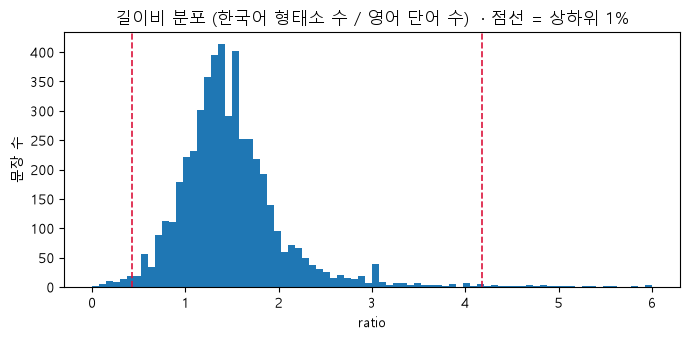


median 1.41 · p1 0.43 · p99 4.18

[ 길이비 상위 3건 — 한국어에 비해 영어가 지나치게 짧다 ]
  ratio  38.0  KO : (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?ca
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total
  ratio  38.0  KO : (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?ca
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total
  ratio  36.0  KO : South Carolina (CNN) ##http://article.joins.com/article/cnn_e/article.
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total

[ 길이비 하위 3건 — 영어가 지나치게 길다 ]
  ratio  0.06  KO : 어휘 :
                EN : the United States will take every measure against what is perhaps grea
  ratio  0.07  KO : 번역 :
                EN : Two bandits shot dead Devi's gang leader lover and took her their vill
  ratio  0.09  KO : 한자사전
                EN : In response, an IAEA inspection team arrived in Korea on Aug.


In [9]:
ratio = ko_mp / np.maximum(en_ws_sample, 1)

plt.figure(figsize=(7, 3.5))
plt.hist(ratio, bins=80, range=(0, 6))
for q, c in [(1, 'crimson'), (99, 'crimson')]:
    plt.axvline(np.percentile(ratio, q), color=c, ls='--', lw=1.2)
plt.title('길이비 분포 (한국어 형태소 수 / 영어 단어 수)  · 점선 = 상하위 1%')
plt.xlabel('ratio'); plt.ylabel('문장 수')
plt.tight_layout(); plt.show()

print(f'\nmedian {np.median(ratio):.2f} · p1 {np.percentile(ratio, 1):.2f} · p99 {np.percentile(ratio, 99):.2f}')

print('\n[ 길이비 상위 3건 — 한국어에 비해 영어가 지나치게 짧다 ]')
for i in np.argsort(-ratio)[:3]:
    j = sample_idx[i]
    print(f'  ratio {ratio[i]:5.1f}  KO : {kor_lines[j][:70]}')
    print(f'                EN : {eng_lines[j][:70]}')

print('\n[ 길이비 하위 3건 — 영어가 지나치게 길다 ]')
for i in np.argsort(ratio)[:3]:
    j = sample_idx[i]
    print(f'  ratio {ratio[i]:5.2f}  KO : {kor_lines[j][:70]}')
    print(f'                EN : {eng_lines[j][:70]}')

### 2-5. 문자 종류 분포

한국어 쪽에 실제로 어떤 문자가 얼마나 섞여 있는지 계산한다.

In [10]:
KEEP_PUNCT = set('?.!,')


def char_class(ch):
    """한 글자를 4절 정규식의 판단 단위로 분류한다."""
    if '가' <= ch <= '힣':                 return '완성형 한글'
    if '\u3131' <= ch <= '\u318e':         return '한글 자모 (ㅋㅋ/ㅠㅠ)'
    if '\u4e00' <= ch <= '\u9fff':         return '한자'
    if '\u3040' <= ch <= '\u30ff':         return '일본어 가나'
    if ch.isascii() and ch.isalpha():      return '라틴 문자'
    if ch.isdigit():                       return '숫자'
    if ch in KEEP_PUNCT:                   return '보존 구두점 (?.!,)'
    return '기타 기호'


cls_counter = Counter()
etc_counter = Counter()
for s in kor_lines:
    for ch in s:
        if ch.isspace():
            continue
        c = char_class(ch)
        cls_counter[c] += 1
        if c == '기타 기호':
            etc_counter[ch] += 1

total = sum(cls_counter.values())
df_char = pd.DataFrame(
    [{'문자 종류': k, '개수': v, '비율': f'{v / total:.2%}'}
     for k, v in cls_counter.most_common()])
display(df_char)

# 4절에서 실제로 지워질 문자들이 무엇인지 눈으로 확인한다.
print('[ "기타 기호" 상위 30종 — 4절 제거 대상 ]')
print('  ' + '  '.join(f'{repr(ch)}x{n:,}' for ch, n in etc_counter.most_common(30)))

,문자 종류,개수,비율
0,완성형 한글,3916063,87.28%
1,라틴 문자,211969,4.72%
2,숫자,145420,3.24%
3,"보존 구두점 (?.!,)",122438,2.73%
4,기타 기호,88854,1.98%
5,한자,1825,0.04%
6,일본어 가나,74,0.00%
7,한글 자모 (ㅋㅋ/ㅠㅠ),7,0.00%


[ "기타 기호" 상위 30종 — 4절 제거 대상 ]
  '“'x14,002  '('x13,920  ')'x13,906  '”'x13,858  '"'x6,561  '’'x4,542  "'"x4,261  '‘'x3,541  '%'x2,714  '-'x2,696  '/'x1,586  '…'x1,189  '~'x990  '&'x787  ':'x709  '['x643  ']'x640  '='x423  '˝'x394  '_'x380  '#'x304  ';'x158  '`'x149  '*'x87  '·'x49  '•'x43  '´'x38  '▶'x31  '$'x21  '）'x20


### 2-6. EDA 정리

| 확인 항목 | 실행 결과 | 반영 |
|---|---|---|
| 형태소 분석기 | `konlpy.tag.Mecab` 실패 → **`mecab_ko.Tagger`** 사용 (동일 MeCab-ko 엔진 + mecab-ko-dic) | - |
| 줄 수 | `.ko` / `.en` 모두 94,123줄로 일치 | - |
| 중복 | 쌍 unique 78,968 · 한국어 77,591 · 영어 75,598<br>같은 한국어에 다른 영어 **1,377건** · 다른 한국어에 같은 영어 **3,370건** | 한국어 기준<br>첫 쌍만 유지 |
| 길이 (표본 5,000, 근사) | 한국어 형태소 mean 29.1 / median 28 / p90 48<br>영어 공백+2 mean 22.9 / median 22 / p90 37 | 길이 컷 |
| 길이 컷 잔존율 (근사) | 30 → 52.7% · **40 → 78.8%** · 50 → 92.2% | 컷 40 채택 |
| 길이비 | median 1.41 · p1 0.43 · p99 4.18<br>이상치는 `##http://...` 링크 줄과 `어휘 :` / `번역 :` / `한자사전` 메타 줄 | 패턴 제거 |
| 문자 종류 | 완성형 한글 87.28% · 라틴 4.72% · **숫자 3.24%** · `?.!,` 2.73% · 기타 기호 1.98% · 한자 0.04% · 가나 0.00% · 자모 7자 | 허용 집합 |

- 길이 통계는 **전처리 전 원본**을 공백/형태소 기준으로 잰 근사값이며, 확정값은 §5-2에서 SentencePiece 조각 길이로 재측정한다.
- 숫자(3.24%)는 한자(0.04%)·자모(7자)와 자릿수가 다르다. **숫자는 보존하고 한자·가나·자모·기타 기호만 제거한다.**

---
# 3. 데이터 정제 - (1) 중복 제거

**한국어 문장을 키로 삼아, 이미 나온 한국어가 다시 등장하면 그 쌍을 건너뛴다.**
같은 인코더 입력에 서로 다른 정답이 붙어 있으면 모델은 어느 쪽으로도 수렴하지 못하고 두 답을 평균낸 듯한 문장을 뱉게 된다.

정확히는 **중복된 한국어를 통째로 버리는 것이 아니라, 가장 먼저 등장한 쌍 하나만 남긴다.**
즉 1,377건의 중복 한국어는 각각 첫 번째 영어 문장만 살아남고 나머지 번역은 버려진다.
`어휘 :` / `번역 :` 처럼 **한국어가 메타 문구라 어떤 영어가 남아도 의미가 없는 줄**은
여기서 걸러지지 않으므로, §4-3의 노이즈 패턴에서 쌍째로 다시 제거한다.

반대로 **다른 한국어에 같은 영어가 붙은 쌍은 지우지 않는다.**
여러 표현이 같은 영어로 번역되는 것은 정상적인 상황이고, 인코더가 다양한 표현을 같은 의미로 묶는 법을 배우는 데 오히려 도움이 된다.

In [11]:
def dedup_parallel(src_lines, trg_lines, key='src'):
    """병렬 쌍을 유지한 채 중복을 제거한다.

    set(src) / set(trg) 를 따로 만들면 개수도 순서도 달라져 대응 관계가 소실된다.
    zip 으로 함께 순회하면서 이미 본 문장이면 '쌍째로' 건너뛰어야 병렬성이 지켜진다.

    주의: 중복 키를 통째로 버리는 것이 아니라 **가장 먼저 등장한 쌍 하나만 남긴다.**
    key='src' 로 부르면 같은 한국어에 붙은 여러 영어 중 첫 번째만 살아남는다.
    """
    seen = set()          # 중복 판정 전용
    kept = []
    for src, trg in zip(src_lines, trg_lines):
        k = src if key == 'src' else (src, trg)
        if k in seen:
            continue      # 이미 본 키 -> 쌍째로 스킵 (첫 쌍만 유지)
        seen.add(k)
        kept.append((src, trg))
    return kept


cleaned_corpus = dedup_parallel(kor_lines, eng_lines, key='src')

print(f'중복 제거 전 : {len(kor_lines):,} 쌍')
print(f'중복 제거 후 : {len(cleaned_corpus):,} 쌍   ({1 - len(cleaned_corpus) / len(kor_lines):.1%} 감소)')

중복 제거 전 : 94,123 쌍
중복 제거 후 : 77,591 쌍   (17.6% 감소)


In [12]:
# 두 기준의 차이가 2-2에서 센 수치와 맞는가
by_pair = dedup_parallel(kor_lines, eng_lines, key='pair')
print(f'한국어 기준 : {len(cleaned_corpus):,} 쌍')
print(f'튜플   기준 : {len(by_pair):,} 쌍')
print(f'차이        : {len(by_pair) - len(cleaned_corpus):,} 쌍')
assert len(by_pair) - len(cleaned_corpus) == u_both - u_ko

# 버려지는 쌍이 실제로 어떻게 생겼는지 확인한다
multi = defaultdict(set)
for ko, en in zip(kor_lines, eng_lines):
    multi[ko].add(en)
multi = {k: v for k, v in multi.items() if len(v) > 1}

print(f'\n한국어 하나에 영어가 여러 개 붙은 문장 : {len(multi):,}개')
print('[ 예시 2건 ] — 이 중 첫 번째로 등장한 쌍 하나만 남는다')
for ko in list(multi)[:2]:
    print(f'  KO : {ko[:70]}')
    for en in list(multi[ko])[:3]:
        print(f'    EN : {en[:70]}')

# 쌍이 깨지지 않았는지 육안 확인
print('\n[ 중복 제거 후 앞 3쌍 ]')
for i, (ko, en) in enumerate(cleaned_corpus[:3]):
    print(f'  [{i}] KO : {ko}')
    print(f'      EN : {en}')

# 중복이 남아있지 않은지 확인
ko_only = [ko for ko, _ in cleaned_corpus]
assert len(ko_only) == len(set(ko_only)), '한국어 중복이 남아있다'

한국어 기준 : 77,591 쌍
튜플   기준 : 78,968 쌍
차이        : 1,377 쌍

한국어 하나에 영어가 여러 개 붙은 문장 : 428개
[ 예시 2건 ] — 이 중 첫 번째로 등장한 쌍 하나만 남는다
  KO : 어휘 :
    EN : aid groups set up freshwater tanks to provide clean drinking water.
    EN : The meeting comes on the heels of a recent UNICEF report on the commer
    EN : still experimental but expected to win approval from the U.S.
  KO : 번역 :
    EN : Using a ground-based telescope to peer into a distant point of light, 
    EN : The study found two new Australian-made cars had very high levels of v
    EN : Two bandits shot dead Devi's gang leader lover and took her their vill

[ 중복 제거 후 앞 3쌍 ]
  [0] KO : 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
      EN : Much of personal computing is about "can you top this?"
  [1] KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
      EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  [2] KO : 그러나 이것은 또한 책상도 필요로 하지 않는다.
      EN : Like 

---
# 4. 데이터 정제 - (2) 노이즈 패턴 제거 · 언어별 정규식 전처리

두 언어는 문자 체계가 다르므로 **전처리 함수를 언어별로 분리**한다.
아래 세 표는 §4-2 / §4-3 코드의 설계 근거이고, 실제 실행 순서는 4-1 → 4-5 이다.

## 설계 (1) 영어 전처리 `preprocess_eng()`

| 단계 | 코드 | 근거 |
|---|---|---|
| 소문자화 | `s.lower().strip()` | `The`/`the`가 서로 다른 vocab 항목이 되는 것을 막는다 |
| 따옴표 정규화 | `’` → `'` | 안 하면 `don’t`가 축약형 사전에 걸리지 않고 `sarkozy’s`가 `sarkozy s`로 쪼개진다 (영어 1,023건) |
| 숫자 내부 구분자 처리 | `1,000` → `1000` · `3.5`의 `.`는 임시 보호 | 다음 단계의 구두점 분리가 `3.5`를 `3 . 5`로 찢는 것을 막는다 |
| 축약형 정규화 | `contractions` 사전 | `don't` / `dont` / `do not`이 각각 다른 토큰이 되는 것을 막는다 |
| 구두점 분리 | `re.sub(r"([?.!,])", r" \1 ", s)` | `split()` 토큰화를 쓰므로 `died.`가 통째로 한 토큰이 되어버린다 |
| 허용 문자 외 제거 | `re.sub(r"[^a-z0-9?.!,']+", " ", s)` | 특수문자 제거. **숫자와 `'`는 남긴다** |
| 따옴표 정리 | 토큰 앞뒤의 `'` 만 제거 | `'yes'`는 없애되 `world's` 내부 `'`는 보존 |
| 특수 토큰 | **여기서는 붙이지 않음** | §5에서 SentencePiece의 `bos_id`/`eos_id`로 등록해 id 시퀀스에 붙인다. 문자열로 붙이면 subword로 쪼개진다 |

## 설계 (2) 한국어 전처리 `preprocess_kor()`

| 단계 | 코드 | 근거 |
|---|---|---|
| 소문자화 | `s.lower().strip()` | 라틴 문자가 4.72% 섞여 있다 (`FTA`, `OECD`) |
| 따옴표 정규화 | `’` → `'` | 한국어 원문에도 곡선 따옴표가 4,542건 있다 |
| 숫자 내부 구분자 처리 | 영어와 동일 | `79.95달러`가 `79 . 95 달러`로 찢기는 것을 막는다 |
| 구두점 분리 | `re.sub(r"([?.!,])", r" \1 ", s)` | 영어와 동일한 이유 |
| **허용 문자 외 제거** | `re.sub(r"[^가-힣a-z0-9?.!,']+", " ", s)` | 아래 상세. `'`는 본문에 섞인 영어 소유격용 |
| 특수 토큰 | **부착하지 않음** | 인코더 입력에는 `<start>`/`<end>`가 필요 없다 |

### `[^가-힣a-z0-9?.!,']` — 허용 목록의 근거

| 문자 종류 | 비율 | 처리 |
|---|---|---|
| 완성형 한글 | 87.28% | 보존 |
| 라틴 문자 | 4.72% | 보존 — `fta`, `oecd` 등 약어 |
| 숫자 | 3.24% | **보존** |
| `? . ! ,` | 2.73% | 보존 |
| 기타 기호 | 1.98% | 제거 — `“ ” ( ) ’ % - / …` |
| 한자 | 0.04% | 제거 — `韓/美/北` 약칭. 대응 영어는 `korea` 등으로 이미 존재한다 |
| 일본어 가나 | 0.00% | 제거 |
| 한글 자모 | 7자 | 제거 — `ㅋㅋ`/`ㅠㅠ`는 형태소 분석기가 의미를 붙이지 못한다 |

**숫자를 보존하는 이유**: 3.24%로 적지 않고, `13개 미군기지` / `3분의 1` 처럼 수량 자체가 문장의 핵심인 경우가 많다.
지우면 소스·타깃 양쪽에서 정보가 사라져 번역이 불가능해진다.

## 설계 (3) 노이즈 패턴 제거

§2-4의 길이비 이상치는 전부 기사 링크 보일러플레이트와 사전·바이라인 메타 줄이었다.
길이비 자체로 자르면 정상 문장까지 휘말리므로 **패턴을 직접 지정해 제거**한다.

### 4-1. 축약형 정규화 사전

In [13]:
# EX08_News_Summary.ipynb 에서 그대로 가져온 축약형 정규화 사전
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print('정규화 사전의 수:', len(contractions))

정규화 사전의 수: 120


### 4-2. 전처리 함수

In [14]:
# 숫자 내부의 소수점의 자리표시자
DEC = "\uE000"


def normalize_quotes(s):
    """곡선 따옴표를 ASCII 로 바꾼다.

    이 처리가 없으면 don’t 가 contractions 사전(키가 ASCII 아포스트로피)에 걸리지 않고,
    sarkozy’s 는 허용 문자 필터에서 ’ 가 지워져 "sarkozy s" 로 쪼개진다.
    """
    return s.replace("‘", "'").replace("’", "'")


def protect_numbers(s):
    """자릿점 콤마는 없애고(1,000 -> 1000), 소수점은 DEC 로 피신시킨다."""
    s = re.sub(r"(?<=\d),(?=\d)", "", s)
    s = re.sub(r"(?<=\d)\.(?=\d)", DEC, s)
    return s


def preprocess_eng(sentence):
    """영어(타깃) 문장 전처리."""
    s = sentence.lower().strip()                   
    s = normalize_quotes(s)                       
    s = protect_numbers(s)                             
    s = re.sub(r"([?.!,])\1+", r"\1", s)                     
    s = re.sub(r"([?.!,])", r" \1 ", s)                  
    s = ' '.join(contractions.get(t, t) for t in s.split())
    s = re.sub(rf"[^a-z0-9?.!,'{DEC}]+", " ", s)
    s = re.sub(r"(^|\s)'+", r"\1", s)                       
    s = re.sub(r"'+(\s|$)", r"\1", s)              
    s = s.replace(DEC, ".")                 
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"^(?:[?.!,] )+", "", s) 
    return s


def preprocess_kor(sentence):
    """한국어(소스) 문장 전처리."""
    s = sentence.lower().strip()      
    s = normalize_quotes(s)                  
    s = protect_numbers(s)                  
    s = re.sub(r"([?.!,])\1+", r"\1", s)        
    s = re.sub(r"([?.!,])", r" \1 ", s)            
    s = re.sub(rf"[^가-힣a-z0-9?.!,'{DEC}]+", " ", s)  
    s = re.sub(r"(^|\s)'+", r"\1", s)                
    s = re.sub(r"'+(\s|$)", r"\1", s)          
    s = s.replace(DEC, ".")     
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"^(?:[?.!,] )+", "", s)
    return s


# 동작 확인
for s in ["The most powerful man all over the world isn't Obama (2024).",
          "Seven people have died -- 3.5% of the 1,200 crew.",
          "Sarkozy’s party won. They don’t agree."]:
    print('EN 원본 :', s)
    print('   결과 :', preprocess_eng(s), '\n')

for s in ["79.95달러하는 이 최첨단 무선 광마우스는 《허공》에서…",
          "韓·美 FTA 협상은 어떻게 되나요? ㅋㅋ",
          "세계 해상 교역량의 거의 3분의 1을 운송한다."]:
    print('KO 원본 :', s)
    print('   결과 :', preprocess_kor(s), '\n')

EN 원본 : The most powerful man all over the world isn't Obama (2024).
   결과 : the most powerful man all over the world is not obama 2024 . 

EN 원본 : Seven people have died -- 3.5% of the 1,200 crew.
   결과 : seven people have died 3.5 of the 1200 crew . 

EN 원본 : Sarkozy’s party won. They don’t agree.
   결과 : sarkozy's party won . they do not agree . 

KO 원본 : 79.95달러하는 이 최첨단 무선 광마우스는 《허공》에서…
   결과 : 79.95달러하는 이 최첨단 무선 광마우스는 허공 에서 

KO 원본 : 韓·美 FTA 협상은 어떻게 되나요? ㅋㅋ
   결과 : fta 협상은 어떻게 되나요 ? 

KO 원본 : 세계 해상 교역량의 거의 3분의 1을 운송한다.
   결과 : 세계 해상 교역량의 거의 3분의 1을 운송한다 . 



### 4-3. 노이즈 패턴 제거

2-4의 길이비 이상치를 확인해 보니 전부 **영어 학습 교재 사이트에서 파싱된 줄**이었다.
길이비로 자르면 정상 문장까지 휘말리므로 패턴을 직접 지정한다.

| 단계 | 대상 | 처리 |
|---|---|---|
| 1 | `##http` · `(JOINS)` · `어휘 :` · `번역 :` · `한자사전` | 쌍째 제거 — 기사 링크 보일러플레이트와 바이라인·사전 줄 |
| 2 | `원문 & 독해설명 인쇄` | **문구만 제거** — 정상 문장 앞에 UI 문구만 붙은 경우가 있어 살릴 수 있다 |
| 3 | 2 처리 후 `2007.02` 같은 날짜로 끝나는 줄 | 쌍째 제거 — 한국어가 기사 제목, 영어가 본문이라 정렬이 어긋나 있다 |
| 4 | 한국어 쪽 ` / ` 가 2개 이상 | 쌍째 제거 — `Army 미국 육군 / shoot down 을 쏘아 떨어뜨리다 / …` 어휘 풀이 나열 |
| 5 | 한글이 하나도 없는 줄 | 쌍째 제거 — `1.` `ST.` 자바스크립트 코드 등 |
| 6 | 한국어가 영어 앞 25자를 그대로 포함 | 쌍째 제거 — 소스에 정답이 들어있어 모델이 번역이 아니라 복사를 학습한다 |

In [15]:
# ---- 쌍째 제거할 보일러플레이트 ----
NOISE_PATTERNS = [
    (r'##http',           '기사 원문 링크 보일러플레이트'),
    (r'\(JOINS\)',        '기자 바이라인 (한국어 쪽에 본문이 없다)'),
    (r'^\s*어휘\s*[:：]',   '사전/학습 메타 줄'),
    (r'^\s*번역\s*[:：]',   '사전/학습 메타 줄'),
    (r'^\s*한자사전',       '사전/학습 메타 줄'),
]
NOISE_RE = re.compile('|'.join(p for p, _ in NOISE_PATTERNS))

UI_RE       = re.compile(r'원문\s*&\s*독해설명\s*인쇄')   # 학습 사이트 UI 문구
HEADLINE_RE = re.compile(r'\d{4}\.\d{2}\s*$')            # "...2007.02" 로 끝나는 제목 줄
GLOSS_RE    = re.compile(r'(?:.* / ){2,}')               # 어휘 풀이
HANGUL_RE   = re.compile(r'[가-힣]')


def is_copied(ko, en, n=25):
    """한국어 줄이 영어 원문의 앞 n자를 그대로 포함하는가."""
    head = re.sub(r'\s+', ' ', en.lower())[:n]
    return len(head) >= n and head in re.sub(r'\s+', ' ', ko.lower())


denoised_corpus = []
removed = Counter()

for ko, en in cleaned_corpus:
    # 보일러플레이트 / 바이라인 / 사전 줄
    if NOISE_RE.search(ko) or NOISE_RE.search(en):
        removed['1. 보일러플레이트·바이라인·사전 줄'] += 1
        continue

    # UI 문구는 문구만 떼어낸다
    had_ui = bool(UI_RE.search(ko))
    ko = re.sub(r'\s+', ' ', UI_RE.sub(' ', ko)).strip()

    # 문구를 뗀 뒤 날짜로 끝나면 기사 제목 줄이다
    if had_ui and HEADLINE_RE.search(ko):
        removed['3. 제목/날짜형'] += 1
        continue

    # 어휘 풀이 나열
    if GLOSS_RE.search(ko):
        removed['4. 어휘 풀이 나열'] += 1
        continue

    # 한글이 하나도 없는 줄
    if not HANGUL_RE.search(ko):
        removed['5. 한글 0자'] += 1
        continue

    # 소스가 타깃을 그대로 포함
    if is_copied(ko, en):
        removed['6. 소스가 타깃 포함'] += 1
        continue

    denoised_corpus.append((ko, en))

print('[ 제거 내역 ]')
for k in sorted(removed):
    print(f'  {k:<28} {removed[k]:>5,} 쌍')
print(f'  {"합계":<28} {sum(removed.values()):>5,} 쌍')

print(f'\n제거 전 : {len(cleaned_corpus):,} 쌍')
print(f'제거 후 : {len(denoised_corpus):,} 쌍   '
      f'({1 - len(denoised_corpus) / len(cleaned_corpus):.2%} 감소)')

[ 제거 내역 ]
  1. 보일러플레이트·바이라인·사전 줄           413 쌍
  3. 제목/날짜형                      195 쌍
  4. 어휘 풀이 나열                     13 쌍
  5. 한글 0자                        20 쌍
  6. 소스가 타깃 포함                   108 쌍
  합계                             749 쌍

제거 전 : 77,591 쌍
제거 후 : 76,842 쌍   (0.97% 감소)


### 4-4. 전처리 적용

In [16]:
kor_prep, eng_prep = [], []
for ko, en in tqdm(denoised_corpus, desc='전처리'):
    kor_prep.append(preprocess_kor(ko))
    eng_prep.append(preprocess_eng(en))

print('\n[ 전처리 전/후 비교 (무작위 3쌍) ]')
for i in random.sample(range(len(denoised_corpus)), 5):
    print(f'  KO 전 : {denoised_corpus[i][0]}')
    print(f'  KO 후 : {kor_prep[i]}')
    print(f'  EN 전 : {denoised_corpus[i][1]}')
    print(f'  EN 후 : {eng_prep[i]}')
    print()

전처리: 100%|██████████| 76842/76842 [00:04<00:00, 18925.51it/s]


[ 전처리 전/후 비교 (무작위 3쌍) ]
  KO 전 : 이 충돌은 14일 코펜하겐 자치부가 노동자들이 공동생활을 하던 낡은 건물을 철거하면서 시작됐다.
  KO 후 : 이 충돌은 14일 코펜하겐 자치부가 노동자들이 공동생활을 하던 낡은 건물을 철거하면서 시작됐다 .
  EN 전 : The clashes started Monday when workers tore down a condemned building in Christiania, a partially self-governing section of Copenhagen that is home to an alternative lifestyle community.
  EN 후 : the clashes started monday when workers tore down a condemned building in christiania , a partially self governing section of copenhagen that is home to an alternative lifestyle community .

  KO 전 : 최근 버마에의 방문에 대해 UN 안전 보장 이사회에서 보고하는 과정에서, 감바리 특사는 이번 방문이 자신이 기대하던 성과를 모두 달성하지는 않았다고 언급했다.
  KO 후 : 최근 버마에의 방문에 대해 un 안전 보장 이사회에서 보고하는 과정에서 , 감바리 특사는 이번 방문이 자신이 기대하던 성과를 모두 달성하지는 않았다고 언급했다 .
  EN 전 : Reporting to the UN security council on his recent visit to the country, Gambari said it had not produced all the results he was hoping for.
  EN 후 : reporting to the un security council on his recent visit to the country , gambari said it had 

### 4-5. 정제 후 검증

1. 정제 결과가 **빈 문장이 된 쌍** 제거
2. 정제 후 **새로 생긴 중복** 제거
3. 허용하지 않은 문자가 남아있지 않은지 확인

In [17]:
# 빈 문장이 된 쌍 제거
nonempty = [(ko, en) for ko, en in zip(kor_prep, eng_prep)
            if ko.strip() and en.strip()]

# 정제 후 새로 생긴 중복 제거
preprocessed_corpus = dedup_parallel([ko for ko, _ in nonempty],
                                     [en for _, en in nonempty], key='pair')

kor_preprocessed = [ko for ko, _ in preprocessed_corpus]
eng_preprocessed = [en for _, en in preprocessed_corpus]

df_stage = pd.DataFrame([
    {'단계': '원본',                    '쌍 수': len(kor_lines)},
    {'단계': '중복 제거',            '쌍 수': len(cleaned_corpus)},
    {'단계': '노이즈 패턴 제거',      '쌍 수': len(denoised_corpus)},
    {'단계': '빈 문장 제거',         '쌍 수': len(nonempty)},
    {'단계': '정제 후 중복 재제거',   '쌍 수': len(preprocessed_corpus)},
])
df_stage['잔존율'] = (df_stage['쌍 수'] / len(kor_lines)).map('{:.1%}'.format)
display(df_stage)

assert len(kor_preprocessed) == len(eng_preprocessed)

,단계,쌍 수,잔존율
0,원본,94123,100.0%
1,중복 제거,77591,82.4%
2,노이즈 패턴 제거,76842,81.6%
3,빈 문장 제거,76840,81.6%
4,정제 후 중복 재제거,76809,81.6%


In [18]:
# 허용하지 않은 문자가 남아있지 않은지 확인
def allowed_ko(ch):
    return ('가' <= ch <= '힣') or ('a' <= ch <= 'z') or ch.isdigit() or ch in KEEP_PUNCT or ch in " '"


def allowed_en(ch):
    return ('a' <= ch <= 'z') or ch.isdigit() or ch in KEEP_PUNCT or ch in " '"


ko_leftover = Counter(ch for s in kor_preprocessed for ch in s if not allowed_ko(ch))
en_leftover = Counter(ch for s in eng_preprocessed for ch in s if not allowed_en(ch))

print('한국어 잔여 비허용 문자 :', dict(ko_leftover.most_common(10)) or '없음')
print('영어   잔여 비허용 문자 :', dict(en_leftover.most_common(10)) or '없음')

print('\n[ 최종 정제 결과 앞 3쌍 ]')
for ko, en in preprocessed_corpus[:3]:
    print(f'  KO : {ko}')
    print(f'  EN : {en}')

한국어 잔여 비허용 문자 : 없음
영어   잔여 비허용 문자 : 없음

[ 최종 정제 결과 앞 3쌍 ]
  KO : 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  EN : much of personal computing is about can you top this ?
  KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .
  KO : 그러나 이것은 또한 책상도 필요로 하지 않는다 .
  EN : like all optical mice , but it also does not need a desk .


---
# 5. 토큰화 & 길이 필터

## 5-1. 형태소 분해 & 코퍼스 파일 저장

한국어만 Mecab 으로 형태소 분해해 공백으로 다시 잇는다.
SentencePiece 는 파일을 입력으로 받으므로 두 언어를 각각 텍스트 파일로 저장한다.

In [19]:
kor_morph = [' '.join(ko_morphs(s)) for s in tqdm(kor_preprocessed, desc='Mecab 형태소 분해')]
eng_text = eng_preprocessed

KOR_CORPUS_PATH = os.path.join(DATA_DIR, 'kor_corpus.txt')
ENG_CORPUS_PATH = os.path.join(DATA_DIR, 'eng_corpus.txt')

with open(KOR_CORPUS_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(kor_morph))
with open(ENG_CORPUS_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(eng_text))

print(f'\n코퍼스 저장 완료 ({len(kor_morph):,} 줄)')

Mecab 형태소 분해: 100%|██████████| 76809/76809 [00:04<00:00, 18569.66it/s]



코퍼스 저장 완료 (76,809 줄)


## 5-2. Vocabulary 크기

세 가지를 함께 본다.

| 지표 | 왜 보는가 |
|---|---|
| 컷40 잔존 | vocab 이 작을수록 한 문장이 더 많은 조각으로 쪼개져 길이 컷 40에 더 많이 걸린다 |
| 영어 희소조각(<5회) | 출력층은 vocab 하나당 `hidden_dim`(512)개의 파라미터를 갖는다. 학습 코퍼스 전량에서 5회도 나오지 않는 조각이 많다는 것은 **거의 학습되지 않는 출력층 행**을 그만큼 들고 다닌다는 뜻이다 |
| 출력층 파라미터 | 모델 전체 파라미터의 절반 이상을 출력층이 차지한다 (§7-3) |

In [20]:
def train_sentencepiece(corpus_path, model_prefix, vocab_size, character_coverage):
    """SentencePiece 모델을 학습하고 로드해서 돌려준다."""
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,
        character_coverage=character_coverage,
        model_type='unigram',
        minloglevel=2,
    )
    sp = spm.SentencePieceProcessor()
    sp.load(model_prefix + '.model')
    return sp


def rare_piece_ratio(sp, lines, min_count=5):
    """학습 코퍼스 전량에서 min_count 회 미만으로만 등장하는 조각의 비율.

    출력층은 vocab 하나당 hidden_dim 개의 파라미터를 갖는데, 그 행이 학습되려면
    해당 조각이 라벨로 충분히 자주 나와야 한다. 이 비율이 높다는 것은
    '거의 학습되지 않는 출력층 행'을 그만큼 들고 다닌다는 뜻이다.
    특수 토큰 4개(pad/bos/eos/unk)는 제외하고 센다.
    """
    freq = Counter()
    for ids in sp.encode(lines):
        freq.update(ids)
    real_ids = range(4, len(sp))
    return sum(1 for i in real_ids if freq[i] < min_count) / len(list(real_ids))


VOCAB_CANDIDATES = [4000, 8000, 16000, 24000, 32000]
SPM_SAMPLE_N = 5000
spm_sample_idx = random.sample(range(len(kor_morph)), SPM_SAMPLE_N)

rows = []
for v in VOCAB_CANDIDATES:
    sp_k = train_sentencepiece(KOR_CORPUS_PATH, os.path.join(DATA_DIR, f'tmp_spm_kor_{v}'), v, 1.0)
    sp_e = train_sentencepiece(ENG_CORPUS_PATH, os.path.join(DATA_DIR, f'tmp_spm_eng_{v}'), v, 1.0)

    kl = np.array([len(sp_k.encode(kor_morph[i])) for i in spm_sample_idx])
    el = np.array([len(sp_e.encode(eng_text[i])) + 2 for i in spm_sample_idx])   # bos/eos 포함

    rows.append({
        'vocab': v,
        '한국어 mean': round(float(kl.mean()), 1),
        '한국어 p90': int(np.percentile(kl, 90)),
        '영어 mean': round(float(el.mean()), 1),
        '영어 p90': int(np.percentile(el, 90)),
        '컷40 잔존': f'{((kl <= 40) & (el <= 40)).mean():.1%}',
        '영어 희소조각(<5회)': f'{rare_piece_ratio(sp_e, eng_text):.1%}',
        '출력층 파라미터': f'{1024 * v / 1e6:.1f}M',
    })
    print(f'  vocab {v:>6} 완료')

display(pd.DataFrame(rows))

# 비교용 임시 모델은 지운다
for f in glob.glob(os.path.join(DATA_DIR, 'tmp_spm_*')):
    os.remove(f)

  vocab   4000 완료
  vocab   8000 완료
  vocab  16000 완료
  vocab  24000 완료
  vocab  32000 완료


,vocab,한국어 mean,한국어 p90,영어 mean,영어 p90,컷40 잔존,영어 희소조각(<5회),출력층 파라미터
0,4000,38.0,59,34.7,55,52.6%,0.1%,4.1M
1,8000,33.7,52,31.2,48,64.3%,0.0%,8.2M
2,16000,31.5,48,29.1,45,71.3%,4.3%,16.4M
3,24000,30.8,48,28.3,44,73.9%,23.6%,24.6M
4,32000,30.4,47,27.9,43,75.2%,41.8%,32.8M


#### 채택: `VOCAB_SIZE = 16,000`

- **잔존율**: 8,000 대비 뚜렷하게 오른다. 반대로 24,000/32,000으로 더 키우면 잔존율 이득은 몇 %p인데 출력층 파라미터는 1.5~2배가 된다.
- **희소조각**: 학습쌍이 55,109개뿐이라 vocab 을 키울수록 `<5회` 조각의 비율이 빠르게 오른다.
  위 표의 `영어 희소조각(<5회)` 열이 16,000에서 크게 튀면 8,000이 더 나은 선택이다.
- 두 지표가 반대 방향이라 중간값인 16,000을 기준으로 잡았다.

## 5-3. SentencePiece 학습 & `<unk>` 점검

`character_coverage` 를 얼마로 둘지는 실제로 두 값을 학습시켜 `<unk>` 비율을 재고 정한다.
한국어는 자주 쓰는 문자 종류가 적어 0.9995 로 두면 드문 글자가 통째로 잘려 나가고,
그 자리가 `<unk>` 가 되면 인코더가 그 토큰에서 아무 정보도 얻지 못한다.

In [21]:
VOCAB_SIZE = 16000
MAX_LEN = 40

encoder_tokenizer = train_sentencepiece(
    KOR_CORPUS_PATH, os.path.join(DATA_DIR, 'deep05_spm_kor'), VOCAB_SIZE, 1.0)
decoder_tokenizer = train_sentencepiece(
    ENG_CORPUS_PATH, os.path.join(DATA_DIR, 'deep05_spm_eng'), VOCAB_SIZE, 1.0)

PAD_ID = decoder_tokenizer.pad_id()
BOS_ID = decoder_tokenizer.bos_id()
EOS_ID = decoder_tokenizer.eos_id()
UNK_ID = decoder_tokenizer.unk_id()

# 특수 토큰 id 는 디코더 쪽에서만 뽑아 쓰는데, 인코더 텐서의 패딩/마스킹에도 그대로 쓰인다.
# 두 토크나이저의 id 가 어긋나면 마스킹이 엉뚱한 자리를 가리키므로 여기서 못 박아 둔다.
assert (encoder_tokenizer.pad_id(), encoder_tokenizer.bos_id(),
        encoder_tokenizer.eos_id(), encoder_tokenizer.unk_id()) == (PAD_ID, BOS_ID, EOS_ID, UNK_ID)

print(f'encoder vocab : {len(encoder_tokenizer):,}')
print(f'decoder vocab : {len(decoder_tokenizer):,}')
print(f'pad={PAD_ID} bos={BOS_ID} eos={EOS_ID} unk={UNK_ID}  (양쪽 토크나이저 동일)')

print('\n[ 조각 분해 예시 ]')
print('  KO :', encoder_tokenizer.encode(kor_morph[0], out_type=str)[:16])
print('  EN :', decoder_tokenizer.encode(eng_text[0], out_type=str)[:16])

encoder vocab : 16,000
decoder vocab : 16,000
pad=0 bos=1 eos=2 unk=3  (양쪽 토크나이저 동일)

[ 조각 분해 예시 ]
  KO : ['▁개인', '▁용', '▁컴퓨터', '▁사용', '▁의', '▁상당', '▁부분', '▁은', '▁이것', '▁보다', '▁뛰어', '날', '▁수', '▁있', '▁느냐', '▁?']
  EN : ['▁much', '▁of', '▁personal', '▁computing', '▁is', '▁about', '▁can', '▁you', '▁top', '▁this', '▁?']


In [22]:
def unk_stats(sp, lines):
    """(<unk> 토큰 비율, <unk> 를 하나라도 포함한 문장 비율)"""
    ids = sp.encode(lines)
    total = sum(len(i) for i in ids)
    unk_tok = sum(i.count(sp.unk_id()) for i in ids)
    unk_sent = sum(1 for i in ids if sp.unk_id() in i)
    return unk_tok / total, unk_sent / len(ids)


# 한국어 쪽에서 coverage 0.9995 와 1.0 을 직접 비교한다.
tmp_prefix = os.path.join(DATA_DIR, 'tmp_spm_cov')
sp_cov = train_sentencepiece(KOR_CORPUS_PATH, tmp_prefix, VOCAB_SIZE, 0.9995)

rows = []
for label, sp in [('0.9995', sp_cov), ('1.0 (채택)', encoder_tokenizer)]:
    r_tok, r_sent = unk_stats(sp, kor_morph)
    rows.append({'character_coverage': label,
                 '<unk> 토큰 비율': f'{r_tok:.4%}',
                 '<unk> 포함 문장 비율': f'{r_sent:.2%}'})

# 영어(디코더) 쪽 최종 토크나이저도 함께 확인한다.
r_tok, r_sent = unk_stats(decoder_tokenizer, eng_text)
print(f'영어 디코더 토크나이저(coverage 1.0) : <unk> 토큰 {r_tok:.4%} · 포함 문장 {r_sent:.2%}\n')

display(pd.DataFrame(rows))

for f in glob.glob(tmp_prefix + '.*'):
    os.remove(f)

영어 디코더 토크나이저(coverage 1.0) : <unk> 토큰 0.0000% · 포함 문장 0.00%



,character_coverage,<unk> 토큰 비율,<unk> 포함 문장 비율
0,0.9995,0.1231%,3.63%
1,1.0 (채택),0.0000%,0.00%


## 5-4. 길이 필터

**양쪽 모두 40 이하**인 쌍만 남긴다.
`MAX_LEN`은 필터 상한과 맞춰 40으로 설정한다. (길이 컷 40은 프로젝트 조건이다)

In [23]:
kor_corpus, eng_corpus, kept_idx = [], [], []

for i, (km, et) in enumerate(zip(kor_morph, eng_text)):
    src = encoder_tokenizer.encode(km)                       # 인코더 입력에는 bos/eos 를 붙이지 않는다
    trg = [BOS_ID] + decoder_tokenizer.encode(et) + [EOS_ID]

    if len(src) <= MAX_LEN and len(trg) <= MAX_LEN:          # 양쪽 모두 만족해야 쌍이 유지된다
        kor_corpus.append(src)
        eng_corpus.append(trg)
        kept_idx.append(i)          # 필터로 인덱스가 밀리므로 원문 위치를 따로 기억한다

assert len(kor_corpus) == len(eng_corpus) == len(kept_idx)
print(f'길이 필터 전 : {len(kor_morph):,} 쌍')
print(f'길이 필터 후 : {len(kor_corpus):,} 쌍   ({len(kor_corpus) / len(kor_morph):.1%} 유지)')

길이 필터 전 : 76,809 쌍
길이 필터 후 : 55,109 쌍   (71.7% 유지)


## 5-5. 검증

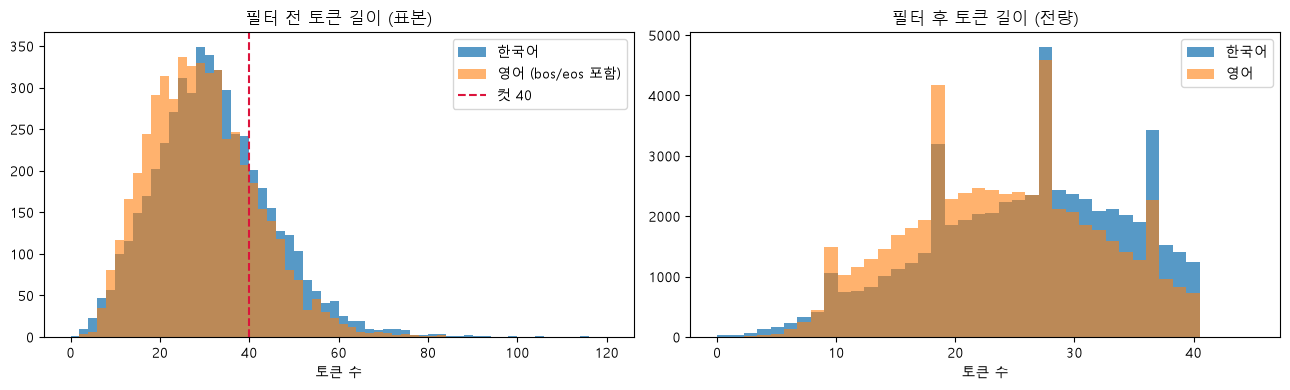

필터 후 한국어 mean 25.9 / max 40
필터 후 영어   mean 24.0 / max 40

[ 라운드트립 — 원문 -> 복원 ]
  원문   : 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  복원   : 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?
  영어   : much of personal computing is about can you top this ?
  원문   : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  복원   : 모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 를 필요 로 하 지 않 는다 .
  영어   : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .


In [24]:
src_len_all = np.array([len(encoder_tokenizer.encode(kor_morph[i])) for i in spm_sample_idx])
trg_len_all = np.array([len(decoder_tokenizer.encode(eng_text[i])) + 2 for i in spm_sample_idx])
src_len_kept = np.array([len(s) for s in kor_corpus])
trg_len_kept = np.array([len(s) for s in eng_corpus])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(src_len_all, bins=60, range=(0, 120), alpha=.75, label='한국어')
axes[0].hist(trg_len_all, bins=60, range=(0, 120), alpha=.6, label='영어 (bos/eos 포함)')
axes[0].axvline(MAX_LEN, color='crimson', ls='--', lw=1.5, label=f'컷 {MAX_LEN}')
axes[0].set_title('필터 전 토큰 길이 (표본)'); axes[0].set_xlabel('토큰 수'); axes[0].legend()

axes[1].hist(src_len_kept, bins=40, range=(0, 45), alpha=.75, label='한국어')
axes[1].hist(trg_len_kept, bins=40, range=(0, 45), alpha=.6, label='영어')
axes[1].set_title('필터 후 토큰 길이 (전량)'); axes[1].set_xlabel('토큰 수'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'필터 후 한국어 mean {src_len_kept.mean():.1f} / max {src_len_kept.max()}')
print(f'필터 후 영어   mean {trg_len_kept.mean():.1f} / max {trg_len_kept.max()}')

print('\n[ 라운드트립 — 원문 -> 복원 ]')
for j in range(2):
    i = kept_idx[j]
    print(f'  원문   : {kor_preprocessed[i]}')
    print(f'  복원   : {encoder_tokenizer.decode(kor_corpus[j])}')
    print(f'  영어   : {decoder_tokenizer.decode(eng_corpus[j])}')

---
# 6. 텐서 변환 & DataLoader

만든 id 시퀀스를 패딩해 텐서로 바꾸고, teacher forcing에 쓸 입력/라벨을 나눈다.

| 텐서 | 구성 | 용도 |
|---|---|---|
| `src` | 한국어 id + post-padding | Encoder 입력 |
| `trg_input` | `full[:-1]` + post-padding | Decoder 입력 |
| `trg_label` | `full[1:]` + post-padding | 정답 라벨 |

텐서는 전량을 `MAX_LEN=40`으로 채워 두되, 배치를 꺼낼 때 `collate_trim()`이 **그 배치의 최장 길이까지만 잘라 낸다**(§6-2).
짧은 문장만 모인 배치가 디코더를 40스텝 다 도는 낭비를 막고, §7의 패딩 마스킹과도 맞물린다.

## 6-1. 패딩 & 텐서 변환

In [25]:
def pad_post(seqs, max_len, pad_id=0):
    """시퀀스 리스트를 뒤쪽 패딩해 (N, max_len) LongTensor 로 만든다."""
    out = torch.full((len(seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out


src_tensor = pad_post(kor_corpus, MAX_LEN, PAD_ID)
trg_input_tensor = pad_post([t[:-1] for t in eng_corpus], MAX_LEN, PAD_ID)   # <s> ... 마지막 단어
trg_label_tensor = pad_post([t[1:] for t in eng_corpus], MAX_LEN, PAD_ID)    # 첫 단어 ... </s>

print('src       :', tuple(src_tensor.shape))
print('trg_input :', tuple(trg_input_tensor.shape))
print('trg_label :', tuple(trg_label_tensor.shape))

src       : (55109, 40)
trg_input : (55109, 40)
trg_label : (55109, 40)


## 6-2. Dataset / DataLoader (배치별 동적 패딩)

In [26]:
BATCH_SIZE = 64


def collate_trim(batch):
    """배치 안에서 가장 긴 문장 길이까지만 잘라 낸다 (동적 패딩).

    모든 문장을 MAX_LEN=40 으로 채워 두면 짧은 문장만 모인 배치도 디코더를 40 스텝 돈다.
    배치별로 잘라 내면 계산량이 줄고, §7 의 패딩 마스킹과도 자연스럽게 맞물린다.
    pad_id 는 0 이고 실제 토큰 id 와 겹치지 않으므로 (!= PAD_ID).sum() 이 곧 실제 길이다.
    """
    src, trg_input, trg_label = (torch.stack(x) for x in zip(*batch))
    src_len = int((src != PAD_ID).sum(1).max())
    trg_len = int((trg_label != PAD_ID).sum(1).max())
    return src[:, :src_len], trg_input[:, :trg_len], trg_label[:, :trg_len]


train_dataset = TensorDataset(src_tensor, trg_input_tensor, trg_label_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_trim)

print(f'학습 샘플 : {len(train_dataset):,}')
print(f'배치 수   : {len(train_loader):,}  (batch_size={BATCH_SIZE})')

for src, trg_input, trg_label in train_loader:
    print('\n[ 배치 shape ] — MAX_LEN 40 이 아니라 배치 최장 길이까지만 남는다')
    print('  src       :', tuple(src.shape))
    print('  trg_input :', tuple(trg_input.shape))
    print('  trg_label :', tuple(trg_label.shape))
    break

학습 샘플 : 55,109
배치 수   : 862  (batch_size=64)

[ 배치 shape ] — MAX_LEN 40 이 아니라 배치 최장 길이까지만 남는다
  src       : (64, 40)
  trg_input : (64, 39)
  trg_label : (64, 39)


---
# 7. 모델 설계 — Encoder / BahdanauAttention / Decoder

## 강의 코드에서 바꾼 부분

| 항목 | 기존 | 이번 프로젝트 |
|---|---|---|
| `input_dim` / `output_dim` | `len(sp_tokenizer)` = 3,000 | `len(encoder_tokenizer)` / `len(decoder_tokenizer)` = **16,000** |
| `evaluate()` 입력 전처리 | 영어용 `preprocess_sentence` | **`preprocess_kor` → `ko_morphs` → `encoder_tokenizer.encode`** 로 교체 |
| `BahdanauAttention` | 소스 전체에 softmax | **`<pad>` 위치를 `-inf` 로 마스킹** — 소스 토큰의 약 35%가 `<pad>` 라 그냥 두면 확률질량이 그쪽으로 샌다 |
| `Encoder` 최종 hidden | `<pad>` 까지 먹은 뒤의 상태 | **`pack_padded_sequence`** 로 마지막 실제 토큰의 상태 |
| `Decoder` RNN 입력 | `embedded` 만 | **`[embedded ; context]`** — context 를 RNN 입력에도 넣는다 (input feeding) |

## Embedding Size / Hidden Size

| 후보 | emb | hid | 비고 |
|---|---|---|---|
| **A (채택)** | 256 | 512 | 하한 기준선 |
| B | 512 | 1024 | vocab 크기가 증가했으니 emb, hidden도 증가 |

§10-1의 비교 결과 **A를 채택**했다. B는 train loss를 24% 낮췄지만 번역은 4문장 중 3개에서 나빠졌고,
epoch 13에서 loss가 반등했다.

## 정규화 — dropout

§10-2에서 A에 dropout 0.3을 걸어 봤지만 4문장 모두 나빠졌다.
따라서 **본 학습은 `DROPOUT = 0.0`** 으로 두고, dropout 구성은 §10-2의 비교 실험으로만 남긴다.

### 7-1. Attention · Encoder · Decoder

In [27]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)   # Encoder의 출력(각 소스 위치의 hidden state)에 곱해질 가중치
        self.W2 = nn.Linear(hidden_dim, hidden_dim)   # Decoder의 현재 hidden state에 곱해질 가중치
        self.v = nn.Linear(hidden_dim, 1, bias=False) # W1, W2를 거쳐 합쳐진 벡터를 스칼라 하나로 압축하는 레이어

    def forward(self, hidden, encoder_outputs, mask=None):
        # hidden: (batch_size, hidden_dim). Decoder의 직전 시점 hidden state
        # encoder_outputs: (src_len, batch_size, hidden_dim). Encoder가 모든 위치에서 낸 hidden state 전체
        # mask: (batch_size, src_len). True 가 실제 토큰, False 가 <pad>

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        # <pad> 자리를 -inf 로 눌러 softmax 확률질량이 그쪽으로 새지 않게 한다.
        # 이 처리가 없으면 소스 토큰의 약 35%(평균 길이 25.9 / MAX_LEN 40)가 <pad> 이므로
        # attention 이 아무 의미도 없는 자리에 가중치를 나눠 주고, 짧은 문장일수록 손해가 커진다.
        if mask is not None:
            attention = attention.masked_fill(~mask, float('-inf'))

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # GRU 가 단층이라 nn.GRU(dropout=...) 는 무시된다(경고만 뜬다).
        # 대신 임베딩 출력에 직접 건다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens=None):
        # src : (src_len, batch_size)  /  src_lens : (batch_size,) 실제 길이
        embedded = self.dropout(self.embedding(src))  # (src_len, batch_size, emb_dim)

        if src_lens is None:
            outputs, hidden = self.rnn(embedded)
        else:
            # pack 하지 않으면 최종 hidden 이 '마지막 실제 토큰'이 아니라
            # 뒤에 붙은 <pad> 들을 전부 먹은 뒤의 상태가 되어 디코더 초기값이 오염된다.
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, src_lens.cpu(), enforce_sorted=False)
            packed_outputs, hidden = self.rnn(packed)
            # <pad> 위치는 0 으로 채워져 돌아온다. 어차피 attention 이 마스킹한다.
            outputs, _ = nn.utils.rnn.pad_packed_sequence(
                packed_outputs, total_length=src.shape[0])

        return outputs, hidden          # outputs : (src_len, batch_size, hidden_dim)


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.0):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Bahdanau 원 구조대로 context vector 를 RNN 입력에도 넣는다 (input feeding).
        # embedding 만 넣으면 디코더 hidden 이 소스 정보를 매 스텝 다시 받지 못해
        # 고빈도 토큰으로 흘러가기 쉽다.
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim)
        # 출력층에는 hidden state 와 attention value 가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        # 임베딩 직후와 출력층 직전, 두 군데에 건다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs, mask=None):
        # input : (batch_size,)  /  hidden : (1, batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)  /  mask : (batch_size, src_len)
        input = input.unsqueeze(0)                      # (1, batch_size)
        embedded = self.dropout(self.embedding(input))  # (1, batch_size, emb_dim)

        # attention distribution 계산. decoder 의 이전 hidden state s_{t-1} 와 encoder 의 H 가 입력된다.
        a = self.attention(hidden[-1], encoder_outputs, mask)  # (batch_size, src_len)

        # H 에 가중치를 부여해 attention value(context vector) 계산
        a = a.unsqueeze(1)                                  # (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)             # (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)                  # (1, batch_size, hidden_dim)

        # RNN 입력 = [embedding ; context]
        rnn_input = torch.cat((embedded, context), dim=2)   # (1, batch_size, emb_dim + hidden_dim)
        output, hidden = self.rnn(rnn_input, hidden)

        # 출력층에서는 현재 hidden state 와 context vector 를 결합해 예측값 생성
        output = output.squeeze(0)    # (batch_size, hidden_dim)
        context = context.squeeze(0)  # (batch_size, hidden_dim)
        prediction = self.fc_out(self.dropout(torch.cat((output, context), dim=1)))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

### 7-2. `Seq2SeqAttention`

`trg` 가 있으면 teacher forcing(학습), 없으면 `<s>` 부터 argmax 자기회귀 생성(추론)이다. 추론에서는 배치 전체가 `</s>` 에 도달하면 조기 종료한다.

In [28]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device, pad_id=0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.pad_id = pad_id

    def forward(self, src, trg=None, max_len=MAX_LEN, bos_id=BOS_ID, eos_id=EOS_ID):
        # 학습에서는 trg_len 만큼, 추론에서는 max_len 까지 동적으로 생성한다.
        batch_size = src.shape[1]

        outputs = []      # 조기 종료를 위해 tensor 가 아닌 리스트로 모은다
        attentions = []   # 시각화를 위해 attention 저장

        # 패딩 마스크는 소스에서 직접 만든다. 추론(문장 1개, 패딩 없음)에서는 전부 True 가 된다.
        mask = (src != self.pad_id).transpose(0, 1)   # (batch_size, src_len)
        src_lens = mask.sum(1)                        # (batch_size,)

        encoder_outputs, hidden = self.encoder(src, src_lens)   # t=1 의 hidden 은 Encoder 의 final state

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]                        # teacher forcing: 정답을 다음 입력으로
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs, mask)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론에는 정답이 없으므로 <s> 를 첫 입력으로 만든다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs, mask)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                top1 = output.argmax(1)
                input = top1

                finished |= (top1 == eos_id)          # 배치 전체가 </s> 를 내면 종료
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)        # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

### 7-3. Embedding / Hidden 크기 — 파라미터 수 비교

In [29]:
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)


def build_model(emb_dim, hid_dim, dropout=0.0, to_device=None):
    """후보 구성으로 모델 하나를 만든다. (dropout 은 파라미터 수에 영향이 없다)"""
    encoder = Encoder(input_dim, emb_dim, hid_dim, dropout)
    attention = BahdanauAttention(hid_dim)
    decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout)
    model = Seq2SeqAttention(encoder, decoder, to_device or torch.device('cpu'), pad_id=PAD_ID)
    return model.to(to_device) if to_device else model


CANDIDATES = [('A (기준)', 256, 512), ('B', 512, 1024)]

rows = []
for name, e, h in CANDIDATES:
    m = build_model(e, h)
    total = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out_layer = m.decoder.fc_out.weight.numel() + m.decoder.fc_out.bias.numel()
    rows.append({'후보': name, 'emb': e, 'hid': h,
                 '전체 파라미터': f'{total / 1e6:.1f}M',
                 '출력층': f'{out_layer / 1e6:.1f}M',
                 '출력층 비중': f'{out_layer / total:.0%}'})
    del m

display(pd.DataFrame(rows))

,후보,emb,hid,전체 파라미터,출력층,출력층 비중
0,A (기준),256,512,28.3M,16.4M,58%
1,B,512,1024,63.9M,32.8M,51%


### 7-4. 모델 생성

In [30]:
# §10-1 비교 결과 A 채택. §10-2 에서 dropout 0.3 은 오히려 나빠졌으므로 본 학습은 0.0 으로 둔다.
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.0

# 아래 model 은 §7-5 의 shape 점검용이다. 실제 학습에 쓰는 모델은
# §9-2 의 run_experiment() 가 실행할 때마다 새로 만든다.
model = build_model(EMB_DIM, HID_DIM, dropout=DROPOUT, to_device=device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n학습 파라미터 : {n_params:,} ({n_params / 1e6:.1f}M)')
print(f'input_dim={input_dim:,}  output_dim={output_dim:,}  '
      f'emb={EMB_DIM}  hid={HID_DIM}  dropout={DROPOUT}')

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(16000, 256)
    (rnn): GRU(768, 512)
    (fc_out): Linear(in_features=1024, out_features=16000, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)

학습 파라미터 : 28,269,696 (28.3M)
input_dim=16,000  output_dim=16,000  emb=256  hid=512  dropout=0.0


### 7-5. shape · 패딩 마스킹 점검

In [31]:
src_b, trg_in_b, trg_lb_b = next(iter(train_loader))

# DataLoader 는 (batch, seq) 로 주지만 모델은 (seq, batch) 를 기대한다.
src_b = src_b.transpose(0, 1).to(device)
trg_in_b = trg_in_b.transpose(0, 1).to(device)
src_len, batch_size = src_b.shape
trg_len = trg_in_b.shape[0]

model.eval()
with torch.no_grad():
    # 1) 학습 경로 — teacher forcing
    outputs, attentions = model(src_b, trg_in_b)
    print('[ 학습 경로 ]')
    print('  outputs    :', tuple(outputs.shape))
    print('  attentions :', tuple(attentions.shape))
    assert outputs.shape == (trg_len, batch_size, output_dim)
    assert attentions.shape == (trg_len, batch_size, src_len)

    # attention 은 소스 위치에 대한 확률분포이므로 행 합이 1이어야 한다.
    assert torch.allclose(attentions.sum(dim=2), torch.ones(trg_len, batch_size, device=device), atol=1e-4)
    print('  attention 행 합 = 1')

    # 패딩 마스킹이 실제로 걸렸는가 — <pad> 자리의 attention 은 0 이어야 한다.
    pad_pos = (src_b == PAD_ID).transpose(0, 1)                     # (batch, src_len)
    pad_attn = attentions.masked_select(pad_pos.unsqueeze(0).expand_as(attentions))
    if pad_attn.numel():
        print(f'  <pad> 비율 {pad_pos.float().mean():.1%}  ·  '
              f'<pad> 자리 attention 최대 {pad_attn.max().item():.2e}')
        assert pad_attn.max().item() < 1e-6, '패딩 마스킹이 걸리지 않았다'
    else:
        print('  이 배치에는 <pad> 가 없다 (전부 같은 길이)')

    # 2) 추론 경로 — trg 없이 <s> 부터 생성, </s> 도달 시 조기 종료
    outputs_i, attentions_i = model(src_b[:, :4])
    print('\n[ 추론 경로 ]')
    print('  outputs    :', tuple(outputs_i.shape))
    print('  attentions :', tuple(attentions_i.shape))
    assert outputs_i.shape[1] == 4 and outputs_i.shape[2] == output_dim
    assert outputs_i.shape[0] <= MAX_LEN

[ 학습 경로 ]
  outputs    : (39, 64, 16000)
  attentions : (39, 64, 39)
  attention 행 합 = 1
  <pad> 비율 35.7%  ·  <pad> 자리 attention 최대 0.00e+00

[ 추론 경로 ]
  outputs    : (40, 4, 16000)
  attentions : (40, 4, 39)


---
# 8. 훈련

### 8-1. Optimizer & Loss

In [32]:
LR = 1e-3
WEIGHT_DECAY = 0.0   # AdamW(weight_decay=0) 은 Adam 과 같다. 정규화 비교(§10-2)에서만 1e-5 를 쓴다.

# optimizer 와 criterion 은 §9-2 의 run_experiment() 가 실행마다 새로 만든다.
# 전역으로 하나만 두면 구성을 바꿔 재실행할 때 이전 실행의 모멘텀이 그대로 딸려온다.
# 여기서는 값의 근거와, 패딩 마스킹이 왜 필요한지만 눈으로 확인한다.

# ignore_index=PAD_ID 가 라벨 쪽 패딩 마스킹이다.
# 이걸 빼면 라벨의 40%가 <pad> 라서 모델이 <pad> 만 뱉어도 loss 가 낮아진다.
criterion_preview = nn.CrossEntropyLoss(ignore_index=PAD_ID)

print(f'optimizer : AdamW | lr = {LR} | weight_decay = {WEIGHT_DECAY}')
print('criterion :', criterion_preview, '| ignore_index =', PAD_ID)

# 마스킹이 실제로 필요한 만큼의 패딩이 있는가
pad_ratio_label = (trg_label_tensor == PAD_ID).float().mean().item()
pad_ratio_src = (src_tensor == PAD_ID).float().mean().item()
print(f'\n라벨 자리의 <pad> 비율  : {pad_ratio_label:.1%}   -> CrossEntropyLoss(ignore_index)')
print(f'소스 자리의 <pad> 비율  : {pad_ratio_src:.1%}   -> Attention mask + pack_padded_sequence (§7-1)')

optimizer : AdamW | lr = 0.001 | weight_decay = 0.0
criterion : CrossEntropyLoss() | ignore_index = 0

라벨 자리의 <pad> 비율  : 42.5%   -> CrossEntropyLoss(ignore_index)
소스 자리의 <pad> 비율  : 35.3%   -> Attention mask + pack_padded_sequence (§7-1)


### 8-2. `train_step()`

In [33]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    """한 epoch 을 학습하고 평균 loss 를 돌려준다."""
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch + 1}', leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader 는 (batch, seq) 배치를 주지만, 모델/Encoder/Decoder 는 (seq, batch) 를 기대한다.
        # 전치하지 않으면 batch 와 seq 축이 뒤바뀐 채 (오류 없이) 잘못 학습된다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)   # teacher forcing

        # (trg_len, batch_size, output_dim) -> (trg_len * batch_size, output_dim)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)   # gradient explosion 방지

        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

---
# 9. 훈련 실행 + 매 epoch 예문 번역

- 매 epoch 4문장을 전부 번역해 기록한다. **어느 epoch 을 최종 결과로 쓸지는 이 기록을 눈으로 보고 고른다**(정성 평가).
- 체크포인트는 train loss 가 갱신된 epoch 의 `best.pt` 하나만 남긴다.
  정성 평가로 고른 epoch 의 가중치가 따로 필요하면 `run_experiment(..., pin_epochs=(8,))` 로 그 epoch 만 추가 저장한다.
- §9-5에서 학습이 끝난 모델의 Attention Map 을 그린다.

### 참고 제출 예시

```
K1) 오바마는 대통령이다.           E1) obama is the president . <end>
K2) 시민들은 도시 속에 산다.        E2) people are victims of the city . <end>
K3) 커피는 필요 없다.              E3) the price is not enough . <end>
K4) 일곱 명의 사망자가 발생했다.     E4) seven people have died . <end>
```

## 9-1. 예문 번역 함수

In [34]:
TEST_SENTENCES = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.',
]


def translate_sentence(sentence, model, max_len=MAX_LEN):
    """한국어 문장 하나를 번역한다.

    Returns:
        text       : 디코딩된 영어 문장 (</s> 로 끝났으면 ' <end>' 를 붙인다)
        pieces     : 생성된 subword 조각 — Attention Map 의 y축 라벨
        src_pieces : 인코더가 실제로 소비한 조각 — x축 라벨
        attention  : (생성 길이, 소스 길이) numpy 배열
    """
    was_training = model.training
    model.eval()

    # 학습 경로와 동일한 순서
    morphed = ' '.join(ko_morphs(preprocess_kor(sentence)))
    src_ids = encoder_tokenizer.encode(morphed)[:max_len]
    src_pieces = encoder_tokenizer.encode(morphed, out_type=str)[:max_len]

    # 문장이 하나뿐이라 패딩하지 않는다.
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(1)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src, max_len=max_len, bos_id=BOS_ID, eos_id=EOS_ID)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    hit_eos = EOS_ID in pred_ids
    if hit_eos:
        pred_ids = pred_ids[:pred_ids.index(EOS_ID)]      # </s> 이후는 버린다

    text = decoder_tokenizer.decode(pred_ids) + (' <end>' if hit_eos else '')
    pieces = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]
    attention = attentions.squeeze(1).cpu().numpy()[:len(pred_ids), :len(src_pieces)]

    if was_training:
        model.train()

    return text, pieces, src_pieces, attention

## 9-2. 실험 실행 함수 `run_experiment()`

구성(A / B / A+dropout)을 바꿔 가며 여러 번 돌려야 하는데, 전역 `model` · `optimizer` · `history` 를 쓰면
- 모델을 새로 만드는 것을 잊으면 **이전 실행의 가중치에서 이어 학습**되고,
- `history` 를 비우지 않으면 서로 다른 구성의 기록이 한 리스트에 섞이고,
- 체크포인트 파일명이 `epochNN.pt` 로 고정돼 **이전 실행이 덮어써진다.**

그래서 실행 하나를 함수로 묶는다. 실행마다 시드를 리셋하고, 체크포인트는 `data/ckpt/<name>/`,
기록은 `data/history/<name>.json` 으로 따로 남겨 §10-3에서 다시 읽는다.

In [35]:
CKPT_DIR = os.path.join(DATA_DIR, 'ckpt')
HIST_DIR = os.path.join(DATA_DIR, 'history')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(HIST_DIR, exist_ok=True)


def run_experiment(name, emb_dim, hid_dim, dropout, epochs,
                   lr=1e-3, weight_decay=0.0, seed=SEED, pin_epochs=()):
    """구성 하나를 처음부터 끝까지 학습하고, 기록을 파일로 남긴다.

    전역 model / optimizer / history 를 쓰면 구성을 바꿔 재실행할 때
    이전 실행의 가중치와 기록이 섞이고 체크포인트가 덮어써진다. 그래서 실행마다
      - 시드를 리셋해 초기화·셔플 순서를 맞추고 (구성 간 비교의 최소 조건)
      - 모델과 optimizer 를 새로 만들고
      - 체크포인트는 data/ckpt/<name>/ 아래에 따로 두고
      - 기록은 data/history/<name>.json 으로 저장해 §10-3 에서 다시 읽는다.

    체크포인트는 train loss 가 갱신된 epoch 의 best.pt 하나만 남긴다.
    정성 평가(§11)로 고른 epoch 의 가중치가 따로 필요하면
    pin_epochs=(8, 11) 처럼 지정해 그 epoch 만 추가로 저장한다.

    Returns:
        dict — {'name', 'config', 'history', 'model'}. model 은 마지막 epoch 상태다.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = build_model(emb_dim, hid_dim, dropout=dropout, to_device=device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    ckpt_dir = os.path.join(CKPT_DIR, name)
    os.makedirs(ckpt_dir, exist_ok=True)

    config = {'name': name, 'emb_dim': emb_dim, 'hid_dim': hid_dim, 'dropout': dropout,
              'epochs': epochs, 'lr': lr, 'weight_decay': weight_decay, 'seed': seed,
              'params': sum(p.numel() for p in model.parameters() if p.requires_grad)}
    print(f'[ {name} ]  emb {emb_dim} · hid {hid_dim} · dropout {dropout} · '
          f'wd {weight_decay} · {config["params"] / 1e6:.1f}M params')

    history, best_loss = [], float('inf')

    for epoch in range(epochs):
        t0 = time.time()
        train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
        elapsed = time.time() - t0

        outs = [translate_sentence(s, model)[0] for s in TEST_SENTENCES]

        is_best = train_loss < best_loss
        if is_best:
            best_loss = train_loss
            torch.save(model.state_dict(), os.path.join(ckpt_dir, 'best.pt'))
        if epoch + 1 in pin_epochs:
            torch.save(model.state_dict(), os.path.join(ckpt_dir, f'epoch{epoch + 1:02d}.pt'))

        print(f'Epoch {epoch + 1:>2}  Train Loss {train_loss:.4f}  ({elapsed:.0f}s)'
              f'{"  <- best 갱신" if is_best else ""}')
        for s, o in zip(TEST_SENTENCES, outs):
            print(f'    {s:<20} -> {o}')
        print()

        history.append({'epoch': epoch + 1, 'loss': train_loss, 'sec': elapsed,
                        'outputs': outs, 'is_best': is_best})

        # 중간에 끊겨도 여기까지의 기록은 남는다.
        with open(os.path.join(HIST_DIR, f'{name}.json'), 'w', encoding='utf-8') as f:
            json.dump({'config': config, 'history': history}, f, ensure_ascii=False, indent=1)

    print(f'{name} 완료 · {len(history)} epoch · 누적 {sum(h["sec"] for h in history) / 60:.0f}분 · '
          f'best loss {best_loss:.4f}')
    return {'name': name, 'config': config, 'history': history, 'model': model}

## 9-3. 본 학습

A 구성(256/512, dropout 0.0)으로 15 epoch 학습한다. 실행당 30~45분 정도 걸린다.

In [36]:
EPOCHS = 15
RUN_NAME = 'A_256_512'

# 정성 평가로 특정 epoch 을 되살려 Attention Map 을 그리고 싶다면
# 아래 pin_epochs 에 그 epoch 번호를 넣고 다시 돌린다. (기본은 best.pt 하나만 저장)
run_A = run_experiment(RUN_NAME, EMB_DIM, HID_DIM, dropout=DROPOUT, epochs=EPOCHS,
                       lr=LR, weight_decay=WEIGHT_DECAY, pin_epochs=())

history = run_A['history']
model = run_A['model']

[ A_256_512 ]  emb 256 · hid 512 · dropout 0.0 · wd 0.0 · 28.3M params


Epoch 1: 100%|██████████| 862/862 [01:29<00:00,  9.69it/s, loss=5.28]


Epoch  1  Train Loss 5.4283  (89s)  <- best 갱신
    오바마는 대통령이다.          -> obama is the president . <end>
    시민들은 도시 속에 산다.       -> the people are still in the city of cities . <end>
    커피는 필요 없다.           -> the company has no immediate . <end>
    일곱 명의 사망자가 발생했다.     -> more than 1800 people were killed in the country's death toll . <end>



Epoch 2: 100%|██████████| 862/862 [01:28<00:00,  9.78it/s, loss=3.95]


Epoch  2  Train Loss 4.1168  (88s)  <- best 갱신
    오바마는 대통령이다.          -> obama is a president . <end>
    시민들은 도시 속에 산다.       -> the citizen is in the city . <end>
    커피는 필요 없다.           -> coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll killed at least 114 people . <end>



...

Epoch  9  Train Loss 1.1755  (87s)  <- best 갱신
    오바마는 대통령이다.          -> obama is a president . <end>
    시민들은 도시 속에 산다.       -> they arrived in downtown cities . <end>
    커피는 필요 없다.           -> skip coffee introduced the coffee . <end>
    일곱 명의 사망자가 발생했다.     -> death , death toll , death toll , death toll , when the dead occurred occurred . <end>



Epoch 10: 100%|██████████| 862/862 [01:28<00:00,  9.79it/s, loss=1.21] 


Epoch 10  Train Loss 1.0325  (88s)  <- best 갱신
    오바마는 대통령이다.          -> obama is a president . <end>
    시민들은 도시 속에 산다.       -> they are citizens from the city . <end>
    커피는 필요 없다.           -> the coffee does not need to do . <end>
    일곱 명의 사망자가 발생했다.     -> death , death toll , death toll , death toll , death toll . <end>



Epoch 11:  78%|███████▊  | 674/862 [01:33<00:26,  7.21it/s, loss=0.997]


KeyboardInterrupt: 

In [39]:
with open(os.path.join(HIST_DIR, 'A_256_512.json'), encoding='utf-8') as f:
    _rec = json.load(f)

model = build_model(EMB_DIM, HID_DIM, dropout=DROPOUT, to_device=device)
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'A_256_512', 'best.pt'), map_location=device))
model.eval()

history = _rec['history']
run_A = {'name': 'A_256_512', 'config': _rec['config'], 'history': history, 'model': model}
print(f"{len(history)} epoch 복구 · best loss {min(h['loss'] for h in history):.4f}")

10 epoch 복구 · best loss 1.0325


## 9-4. 학습 곡선 & epoch별 번역 기록

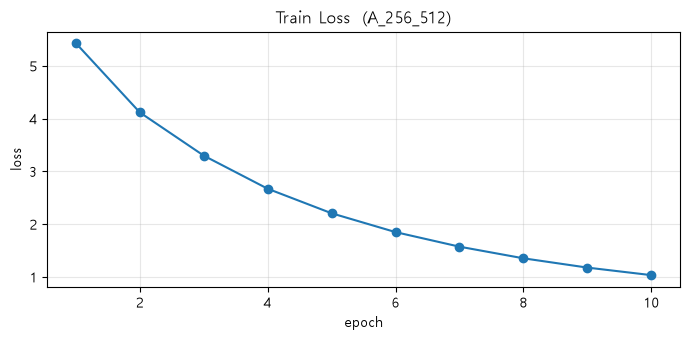

loss 5.4283 -> 1.0325  (81.0% 감소)
최저 loss 1.0325 (epoch 10) -> data/ckpt/A_256_512/best.pt


In [40]:
plt.figure(figsize=(7, 3.5))
plt.plot([h['epoch'] for h in history], [h['loss'] for h in history], marker='o')
plt.title(f'Train Loss  ({run_A["name"]})'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

first, last = history[0]['loss'], history[-1]['loss']
best = min(history, key=lambda h: h['loss'])
print(f'loss {first:.4f} -> {last:.4f}  ({(first - last) / first:.1%} 감소)')
print(f'최저 loss {best["loss"]:.4f} (epoch {best["epoch"]}) -> data/ckpt/{run_A["name"]}/best.pt')

In [41]:
rows = []
for h in history:
    row = {'epoch': h['epoch'], 'loss': round(h['loss'], 4)}
    for k, o in enumerate(h['outputs'], 1):
        row[f'K{k}'] = o
    rows.append(row)

pd.set_option('display.max_colwidth', 70)
display(pd.DataFrame(rows))

print('K1 오바마는 대통령이다.   K2 시민들은 도시 속에 산다.')
print('K3 커피는 필요 없다.      K4 일곱 명의 사망자가 발생했다.')

,epoch,loss,K1,K2,K3,K4
0,1,5.4283,obama is the president . <end>,the people are still in the city of cities . <end>,the company has no immediate . <end>,more than 1800 people were killed in the country's death toll . <end>
1,2,4.1168,obama is a president . <end>,the citizen is in the city . <end>,coffee coffee coffee coffee coffee coffee coffee coffee coffee cof...,the death toll killed at least 114 people . <end>
2,3,3.2976,obama is a president . <end>,the citizens are required to see the city's downtown city . <end>,the coffee does not need to be needed . <end>,the death toll killed at least 114 people . <end>
3,4,2.6702,obama is president . <end>,they are citizens . <end>,it is not necessary . <end>,"death toll died when death tolls dead , death toll . <end>"
4,5,2.2050,obama is a president . <end>,they are citizens in the city . <end>,it is not necessary . <end>,the death toll killed at least seven deaths . <end>
5,6,1.8480,obama is a president . <end>,citizens are citizens in the city . <end>,the coffee does not need necessary . <end>,seven deaths died when the dead were killed . <end>
6,7,1.5720,obama is a president . <end>,they are citizens in a downtown city . <end>,it is never necessary . <end>,death toll occurred . <end>
7,8,1.3515,obama is a president . <end>,the citizens are citizens in the downtown city . <end>,it is never required . <end>,"death , death toll , death toll . <end>"
8,9,1.1755,obama is a president . <end>,they arrived in downtown cities . <end>,skip coffee introduced the coffee . <end>,"death , death toll , death toll , death toll , when the dead occur..."
9,10,1.0325,obama is a president . <end>,they are citizens from the city . <end>,the coffee does not need to do . <end>,"death , death toll , death toll , death toll , death toll . <end>"


K1 오바마는 대통령이다.   K2 시민들은 도시 속에 산다.
K3 커피는 필요 없다.      K4 일곱 명의 사망자가 발생했다.


## 9-5. Attention Map

디코더가 각 영어 조각을 낼 때 한국어 소스의 어느 위치를 봤는지 그린다.
한 행이 소스 위치에 대한 확률분포이므로 **행 합은 1**이고, `<pad>` 자리는 마스킹돼 0이다(§7-1).
`translate_sentence()` 는 문장 하나만 넣으므로 애초에 패딩이 없고, x축에는 실제 소비한 조각만 남는다.

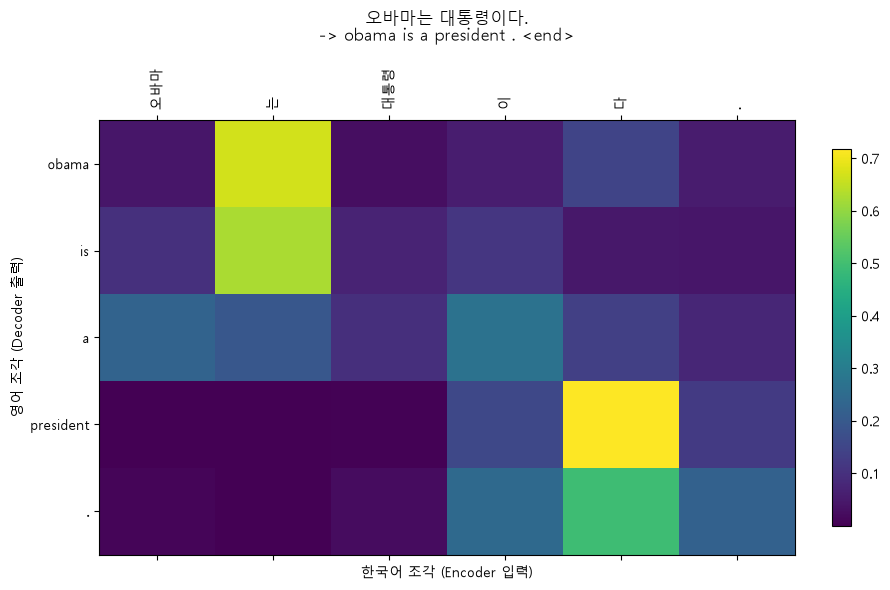

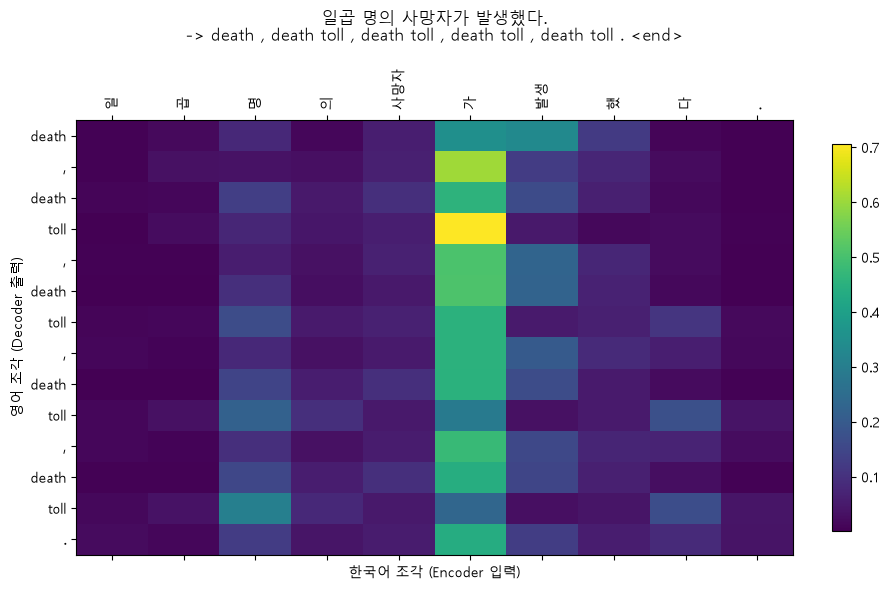

In [42]:
def plot_attention(sentence, model, figsize=(9, 6)):
    """한 문장을 번역하고 attention 가중치를 히트맵으로 그린다.

    x축 : 인코더가 소비한 한국어 조각 (형태소 분해 -> SentencePiece)
    y축 : 디코더가 생성한 영어 조각
    밝을수록 그 시점에 해당 소스 위치를 크게 참조했다는 뜻이다.
    """
    text, pieces, src_pieces, attention = translate_sentence(sentence, model)
    if not pieces:
        print(f'{sentence} -> 생성된 토큰이 없다 (첫 스텝에서 </s>)')
        return text

    def clean(ps):
        # SentencePiece 의 어두 표시 '▁' 는 축에 그대로 두면 읽기 어렵다.
        return [p.replace('\u2581', ' ').strip() or '_' for p in ps]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(attention, cmap='viridis', aspect='auto')
    fig.colorbar(im, ax=ax, fraction=.025)

    ax.set_xticks(range(len(src_pieces)))
    ax.set_xticklabels(clean(src_pieces), rotation=90)
    ax.set_yticks(range(len(pieces)))
    ax.set_yticklabels(clean(pieces))
    ax.set_xlabel('한국어 조각 (Encoder 입력)')
    ax.set_ylabel('영어 조각 (Decoder 출력)')
    ax.set_title(f'{sentence}\n-> {text}', pad=20)

    plt.tight_layout(); plt.show()
    return text


# 학습이 끝난 모델(마지막 epoch)로 두 문장을 확인한다.
for s in (TEST_SENTENCES[0], TEST_SENTENCES[3]):
    plot_attention(s, model)

---
# 10. 최종 결과


| | 값 |
|---|---|
| 선택한 epoch | *10* |
| 실행 조건 | A (256/512) · dropout 0.0 · 15 epoch · 패딩 마스킹 + input feeding |
| 고른 이유 | *문장이 가장 완성형이다* |


> ```
> K1) 오바마는 대통령이다.          E1) obama is a president . <end>
> K2) 시민들은 도시 속에 산다.       E2) they are citizens from the city . <end>
> K3) 커피는 필요 없다.             E3) the coffee does not need to do . <end>
> K4) 일곱 명의 사망자가 발생했다.    E4) death , death toll , death toll , death toll , death toll . <end>
> ```

In [45]:
CHOSEN_RUN = RUN_NAME     # 9-3에서 돌린 구성
CHOSEN_EPOCH = None       # None 이면 best.pt. 정성 평가로 고른 epoch 이 따로 있으면 그 번호를 넣는다.

ckpt_name = 'best.pt' if CHOSEN_EPOCH is None else f'epoch{CHOSEN_EPOCH:02d}.pt'
ckpt_path = os.path.join(CKPT_DIR, CHOSEN_RUN, ckpt_name)
assert os.path.exists(ckpt_path), (
    f'{ckpt_path} 가 없다. best.pt 외의 epoch 을 쓰려면 '
    f'run_experiment(..., pin_epochs=({CHOSEN_EPOCH},)) 로 그 epoch 을 먼저 저장해야 한다.')

# 학습 때와 같은 구성으로 껍데기를 만들고 가중치만 얹는다.
final_model = build_model(EMB_DIM, HID_DIM, dropout=DROPOUT, to_device=device)
final_model.load_state_dict(torch.load(ckpt_path, map_location=device))
final_model.eval()

print(f'[ {CHOSEN_RUN} / {ckpt_name} ]  emb {EMB_DIM} · hid {HID_DIM} · dropout {DROPOUT}\n')
for i, s in enumerate(TEST_SENTENCES, 1):
    print(f'  K{i}) {s:<22} E{i}) {translate_sentence(s, final_model)[0]}')

[ A_256_512 / best.pt ]  emb 256 · hid 512 · dropout 0.0

  K1) 오바마는 대통령이다.            E1) obama is a president . <end>
  K2) 시민들은 도시 속에 산다.         E2) they are citizens from the city . <end>
  K3) 커피는 필요 없다.             E3) the coffee does not need to do . <end>
  K4) 일곱 명의 사망자가 발생했다.       E4) death , death toll , death toll , death toll , death toll . <end>


### Attention Map — 최종 모델

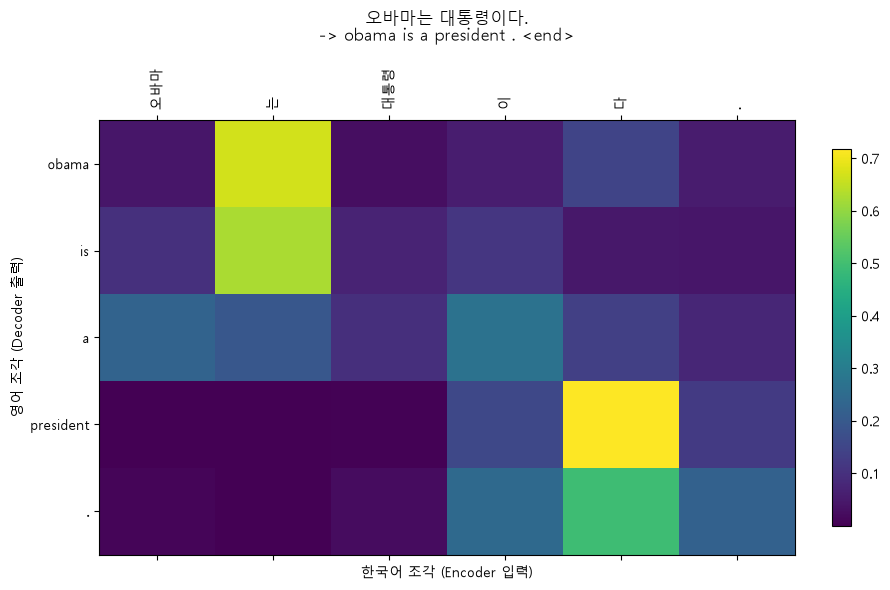

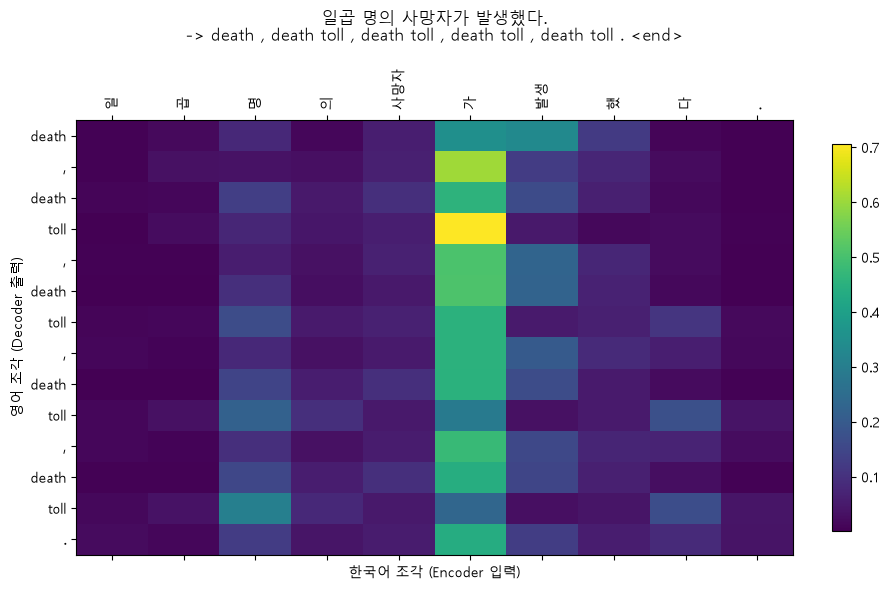

In [44]:
for s in (TEST_SENTENCES[0], TEST_SENTENCES[3]):
    plot_attention(s, final_model)

---
# 12. 회고


## 배운 점
- 병렬 코퍼스에서 `set`으로 중복을 제거할 때 쌍을 유지하는 방법을 배웠다. 다만 이 방식은 중복 키를 통째로 버리는 게 아니라 **첫 쌍만 남기는** 것이라, `어휘 :` 같은 메타 줄은 §4-3의 패턴 제거로 따로 걸러야 했다.
- EDA로 학습 교재 사이트 UI 문구, 어휘 풀이 나열, 소스에 정답이 그대로 들어간 문장 같은 노이즈를 직접 찾아 제거하면서, 전처리는 감이 아니라 실측 수치로 결정해야 한다는 것을 배웠다. 같은 이유로 SentencePiece의 `character_coverage`도 0.9995와 1.0을 직접 학습시켜 `<unk>` 비율을 재 보고 1.0을 골랐다(§5-3).
- **패딩을 마스킹하지 않으면 attention 이 조용히 망가진다.** 소스 토큰의 35%가 `<pad>`인데 softmax 가 그 자리까지 포함해 정규화되면 확률질량이 아무 의미 없는 곳으로 새고, 인코더의 최종 hidden 도 `<pad>`를 다 먹은 뒤의 상태가 되어 디코더 초기값이 오염된다. 에러가 나지 않아 더 위험한 종류의 버그였다.
- 모델을 키워도(B), 정규화를 추가해도(dropout) 번역 품질이 개선되지 않고 오히려 반복 루프가 심해졌다. train loss는 두 경우 모두에서 유의미하게 움직였지만 그 방향이 품질과는 무관했다. 서로 반대 방향의 두 실험이 모두 실패했다는 사실 자체가, 원인이 모델 용량이 아니라 다른 곳(패딩 마스킹, 디코딩 방식, teacher forcing)에 있다는 신호라는 것을 이번에 배웠다.


## 아쉬운 점 / 한계
- 검증셋을 두지 않아 일반화 성능을 수치로 말할 수 없다. train loss만으로는 과적합 여부를 단정할 수 없다는 점도 10-1을 쓰면서 걸렸다.
- teacher forcing 100%, greedy decoding으로 인한 반복 루프가 남아 있다. 재학습 없이 시도할 수 있는 beam search나 repetition penalty를 시도하지 못했고, scheduled sampling을 적용했을 때 어느 정도 성능이 향상되는지도 확인하지 못했다.
- 처음에는 체크포인트 파일명이 `epochNN.pt`로 고정돼 있어 새 구성(B, 정규화)을 돌릴 때마다 이전 실행의 체크포인트가 덮어써졌고, 전역 `history`도 실행 간에 섞였다.